# Comparison of Two Time Series of Maps 0.1
*This notebook implements the framework from the article “Foundational concepts and equations to compare two time series of maps” to quantify and visualize agreement and change between two temporal map series. Using toy data, it defines modular Python functions to compute presence‐agreement components, gains and losses, and full‐extent change metrics, and produces visualizations and exportable results for reproducible analysis.*

## 1. Environmental Setup

### 1.1 Load Libraries

In [1]:
# =============================================================================
# 1. Load Libraries
# =============================================================================
import os
import rasterio
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

from matplotlib.colors import ListedColormap, BoundaryNorm
from matplotlib.ticker import FuncFormatter
from matplotlib_scalebar.scalebar import ScaleBar
from matplotlib_map_utils import north_arrow

from pyproj import Transformer
from rasterio.enums import Resampling

### 1.2 Set Parameters

In [8]:
# =============================================================================
# 1. Set the parameters
# =============================================================================

# Input raster maps:
# path_series_x = r"C:\Users\AntFonseca\github\1.INPUT\compare-time-series\PIE\pixelbased"
# path_series_y = r"C:\Users\AntFonseca\github\1.INPUT\compare-time-series\PIE\objectbased"
# time_points = [2010, 2012, 2014, 2016, 2018, 2021]
# class_name = "PIE"
# is_binary_data = True # Set to True for 0/1 data

# path_series_x = r"C:\Users\AntFonseca\github\compare-time-series\input\pieBasZoom2"
# path_series_y = r"C:\Users\AntFonseca\github\compare-time-series\input\pieObjZoom2"
# time_points = [2010, 2012, 2014, 2016, 2018, 2021]
# class_name = "PIE"
# is_binary_data = True # Set to True for 0/1 data

# path_series_x = r"C:\Users\AntFonseca\github\1.INPUT\compare-time-series\collection6"
# path_series_y = r"C:\Users\AntFonseca\github\1.INPUT\compare-time-series\collection8"
# time_points = [1990, 1995, 2000, 2005, 2010, 2015, 2020]
# class_name = "savanna"
# is_binary_data = True

path_series_x = r"C:\Users\AntFonseca\github\1.INPUT\deforestation\westernCol9"
path_series_y = r"C:\Users\AntFonseca\github\1.INPUT\deforestation\westernCol9"
# time_points = [2008, 2009, 2010, 2011, 2012,
#                2013, 2014, 2015, 2016, 2017,
#                2018, 2019, 2020, 2021, 2022,
#                2023]
time_points = list(range(1987, 2024))
class_name = "def"
is_binary_data = True

# path_series_x = r"C:\Users\AntFonseca\github\1.INPUT\compare-time-series\soilCol1"
# path_series_y = r"C:\Users\AntFonseca\github\1.INPUT\compare-time-series\soilCol2"
# time_points = [1990, 2000, 2010]
# class_name = "soil"
# is_binary_data = False

# path_series_x = r"C:\Users\AntFonseca\github\1.INPUT\compare-time-series\toydata\x"
# path_series_y = r"C:\Users\AntFonseca\github\1.INPUT\compare-time-series\toydata\y"
# time_points = [0, 1, 2]
# class_name = "toydata"
# is_binary_data = True

# Output folder
output_path = fr"C:\Users\AntFonseca\github\2.OUTPUT\{class_name}"
if not os.path.exists(output_path):
    os.makedirs(output_path)

# NoData values
nodata_value = 255 #-32768

print("✅ Parameters successfully defined.")

✅ Parameters successfully defined.


## 2. Definition of Calculation Functions

In [9]:
# =============================================================================
# 1. Definition of all calculation functions
# =============================================================================

# -----------------------------------------------------------------------------
# 1.1 Helper function for data reading
# -----------------------------------------------------------------------------
raster_arrays = {}

def get_raster_array(year):
    """
    Reads a pair of raster files (x and y) for a given year
    or returns it from the cache if already loaded.
    """
    if year in raster_arrays:
        return raster_arrays[year]
    
    file_name = f"{class_name}{year}.tif"
    
    path_x = os.path.join(
        path_series_x,
        file_name
    )
    path_y = os.path.join(
        path_series_y,
        file_name
    )

    if (
        not os.path.exists(path_x) or
        not os.path.exists(path_y)
    ):
        print(
            f"Warning: File '{file_name}' not found for year {year}."
        )
        return None, None

    with rasterio.open(path_x) as src_x, rasterio.open(path_y) as src_y:
        array_x = src_x.read(1)
        array_y = src_y.read(1)
        raster_arrays[year] = (array_x, array_y)
        return array_x, array_y


# -----------------------------------------------------------------------------
# 1.2 Metrics calculation functions
# -----------------------------------------------------------------------------
def calculate_presence_metrics(file_x, file_y):
    """
    Calculates presence agreement metrics for a single time point.
    """
    with rasterio.open(file_x) as src_x, rasterio.open(file_y) as src_y:
        array_x = src_x.read(1)
        array_y = src_y.read(1)
        
        valid_mask = (
            (array_x != nodata_value) &
            (array_y != nodata_value)
        )
        
        presence_x = array_x[valid_mask]
        presence_y = array_y[valid_mask]
        
        hits = np.sum(np.minimum(presence_x, presence_y))
        total_x = np.sum(presence_x)
        total_y = np.sum(presence_y)
        
        hits = hits.astype(np.int64)
        total_x = total_x.astype(np.int64)
        total_y = total_y.astype(np.int64)
        
        space_difference = np.minimum(total_x, total_y) - hits
        misses = np.maximum(0, total_x - total_y)
        false_alarms = np.maximum(0, total_y - total_x)
        
        return {
            "Hit": hits,
            "Miss": misses,
            "False Alarm": false_alarms,
            "Space Difference": space_difference,
            "Total X": total_x,
            "Total Y": total_y
        }


def calculate_change_metrics(year_t, year_t_minus_1):
    """
    Calculates all gross change metrics (gains and losses)
    for a single time interval.
    """
    array_x_t, array_y_t = get_raster_array(year_t)
    array_x_t_minus_1, array_y_t_minus_1 = get_raster_array(year_t_minus_1)

    if array_x_t is None or array_x_t_minus_1 is None:
        return None

    valid_mask = (
        (array_x_t != nodata_value) &
        (array_y_t != nodata_value) &
        (array_x_t_minus_1 != nodata_value) &
        (array_y_t_minus_1 != nodata_value)
    )

    change_x = np.subtract(
        array_x_t,
        array_x_t_minus_1,
        dtype=np.int16
    )
    change_y = np.subtract(
        array_y_t,
        array_y_t_minus_1,
        dtype=np.int16
    )

    gain_x = np.maximum(0, change_x)
    gain_y = np.maximum(0, change_y)
    loss_x = np.minimum(0, change_x)
    loss_y = np.minimum(0, change_y)
    
    gain_total_x = np.sum(gain_x)
    gain_total_y = np.sum(gain_y)
    loss_total_x = np.sum(loss_x)
    loss_total_y = np.sum(loss_y)
    
    gain_hit = np.sum(np.minimum(gain_x, gain_y))
    gain_space_diff = np.minimum(gain_total_x, gain_total_y) - gain_hit
    gain_miss = np.maximum(0, gain_total_x - gain_total_y)
    gain_false_alarm = np.maximum(0, gain_total_y - gain_total_x)

    loss_hit = np.sum(np.maximum(loss_x, loss_y))
    loss_space_diff = np.maximum(loss_total_x, loss_total_y) - loss_hit
    loss_miss = np.minimum(0, loss_total_x - loss_total_y)
    loss_false_alarm = np.minimum(0, loss_total_y - loss_total_x)
    
    return {
        "Gain Hits": gain_hit,
        "Gain Miss": gain_miss,
        "Gain False Alarm": gain_false_alarm,
        "Gain Space Difference": gain_space_diff,
        "Loss Hits": loss_hit,
        "Loss Miss": loss_miss,
        "Loss False Alarm": loss_false_alarm,
        "Loss Space Difference": loss_space_diff,
        "Gain Total X": gain_total_x,
        "Gain Total Y": gain_total_y,
        "Loss Total X": loss_total_x,
        "Loss Total Y": loss_total_y
    }


def calculate_extent_metrics(time_points_list):
    """
    Calculates gross change metrics for the entire temporal extent.
    """
    start_year, end_year = (
        time_points_list[0],
        time_points_list[-1]
    )
    
    array_x_start, array_y_start = get_raster_array(start_year)
    array_x_end, array_y_end = get_raster_array(end_year)

    if array_x_start is None or array_x_end is None:
        return None

    valid_mask = (
        (array_x_start != nodata_value) &
        (array_y_start != nodata_value) &
        (array_x_end != nodata_value) &
        (array_y_end != nodata_value)
    )

    change_x = np.subtract(
        array_x_end,
        array_x_start,
        dtype=np.int16
    )
    change_y = np.subtract(
        array_y_end,
        array_y_start,
        dtype=np.int16
    )

    gain_x = np.maximum(0, change_x)
    gain_y = np.maximum(0, change_y)
    loss_x = np.minimum(0, change_x)
    loss_y = np.minimum(0, change_y)
    
    gain_total_x = np.sum(gain_x)
    gain_total_y = np.sum(gain_y)
    loss_total_x = np.sum(loss_x)
    loss_total_y = np.sum(loss_y)

    gain_hit = np.sum(np.minimum(gain_x, gain_y))
    gain_space_diff = np.minimum(gain_total_x, gain_total_y) - gain_hit
    gain_miss = np.maximum(0, gain_total_x - gain_total_y)
    gain_false_alarm = np.maximum(0, gain_total_y - gain_total_x)

    loss_hit = np.sum(np.maximum(loss_x, loss_y))
    loss_space_diff = np.maximum(loss_total_x, loss_total_y) - loss_hit
    loss_miss = np.minimum(0, loss_total_x - loss_total_y)
    loss_false_alarm = np.minimum(0, loss_total_y - loss_total_x)
    
    return {
        "Gain Hits": gain_hit,
        "Gain Miss": gain_miss,
        "Gain False Alarm": gain_false_alarm,
        "Gain Space Difference": gain_space_diff,
        "Loss Hits": loss_hit,
        "Loss Miss": loss_miss,
        "Loss False Alarm": loss_false_alarm,
        "Loss Space Difference": loss_space_diff
    }


def calculate_net_change_components(gross_results):
    """
    Calculates the Net Change components from Gross Change results.
    """
    if not gross_results:
        return None
        
    Ght = gross_results.get("Gain Hits", 0)
    Gut = gross_results.get("Gain Space Difference", 0)
    Gmt = gross_results.get("Gain Miss", 0)
    Gft = gross_results.get("Gain False Alarm", 0)
    Lht = gross_results.get("Loss Hits", 0)
    Lut = gross_results.get("Loss Space Difference", 0)
    Lmt = gross_results.get("Loss Miss", 0)
    Lft = gross_results.get("Loss False Alarm", 0)

    QGxt = np.maximum(0, Ght + Gut + Gmt + Lht + Lut + Lmt)
    QGyt = np.maximum(0, Ght + Gut + Gft + Lht + Lut + Lft)
    QLxt = np.minimum(0, Ght + Gut + Gmt + Lht + Lut + Lmt)
    QLyt = np.minimum(0, Ght + Gut + Gft + Lht + Lut + Lft)

    net_gain_hit = np.minimum(QGxt, QGyt)
    net_gain_miss = np.maximum(0, QGxt - QGyt)
    net_gain_false_alarm = np.maximum(0, QGyt - QGxt)
    
    net_loss_hit = np.maximum(QLxt, QLyt)
    net_loss_miss = np.minimum(0, QLxt - QLyt)
    net_loss_false_alarm = np.minimum(0, QLyt - QLxt)
    
    return {
        "Gain Hits": net_gain_hit,
        "Gain Miss": net_gain_miss,
        "Gain False Alarm": net_gain_false_alarm,
        "Loss Hits": net_loss_hit,
        "Loss Miss": net_loss_miss,
        "Loss False Alarm": net_loss_false_alarm,
        "QG_Total_X": QGxt,
        "QG_Total_Y": QGyt,
        "QL_Total_X": QLxt,
        "QL_Total_Y": QLyt
    }

print("✅ All calculation functions are defined.")

✅ All calculation functions are defined.


## 3. Execute the functions

In [12]:
# =============================================================================
# 1. Central execution of all calculations
# =============================================================================
print("Starting all data processing and calculations...")

# -----------------------------------------------------------------------------
# 1.1 Presence Hits Calculations
# -----------------------------------------------------------------------------
print("\nCalculating Presence Hits metrics...")

results_by_time = {}
for year in time_points:
    file_name = f"{class_name}{year}.tif"
    file_x = os.path.join(path_series_x, file_name)
    file_y = os.path.join(path_series_y, file_name)
    if os.path.exists(file_x) and os.path.exists(file_y):
        results_by_time[year] = calculate_presence_metrics(file_x, file_y)

sum_results = {
    "Hit": 0,
    "Space Difference": 0,
    "Total X": 0,
    "Total Y": 0
}
for year in results_by_time:
    sum_results["Hit"] += results_by_time[year]["Hit"]
    sum_results["Space Difference"] += results_by_time[year]["Space Difference"]
    sum_results["Total X"] += results_by_time[year]["Total X"]
    sum_results["Total Y"] += results_by_time[year]["Total Y"]

sum_results["Time Difference"] = (
    np.minimum(sum_results["Total X"], sum_results["Total Y"])
    - sum_results["Hit"]
    - sum_results["Space Difference"]
)
sum_results["Miss"] = np.maximum(0, sum_results["Total X"] - sum_results["Total Y"])
sum_results["False Alarm"] = np.maximum(0, sum_results["Total Y"] - sum_results["Total X"])

print("Presence Hits calculations complete.")

# -----------------------------------------------------------------------------
# 1.2 Gross Change Calculations
# -----------------------------------------------------------------------------
print("\nCalculating Gross Change metrics...")

change_results_by_interval = {}
time_intervals = []
for i in range(1, len(time_points)):
    year_t = time_points[i]
    year_t_minus_1 = time_points[i - 1]
    interval_label = f"{year_t_minus_1}-{year_t}"
    time_intervals.append(interval_label)
    change_results_by_interval[interval_label] = calculate_change_metrics(year_t, year_t_minus_1)

extent_results = calculate_extent_metrics(time_points)

sum_change_results = {
    "Gain Hits": 0,
    "Gain Space Difference": 0,
    "Gain Miss": 0,
    "Gain False Alarm": 0,
    "Gain Total X": 0,
    "Gain Total Y": 0,
    "Gain Time Difference": 0,
    "Loss Hits": 0,
    "Loss Space Difference": 0,
    "Loss Miss": 0,
    "Loss False Alarm": 0,
    "Loss Total X": 0,
    "Loss Total Y": 0,
    "Loss Time Difference": 0,
}
for interval in time_intervals:
    results = change_results_by_interval.get(interval)
    if results:
        for key in [
            "Gain Hits", "Gain Space Difference", "Gain Miss", "Gain False Alarm",
            "Gain Total X", "Gain Total Y",
            "Loss Hits", "Loss Space Difference", "Loss Miss", "Loss False Alarm",
            "Loss Total X", "Loss Total Y"
        ]:
            sum_change_results[key] += results[key]

# Derive time-difference terms for the sum row
sum_change_results["Gain Time Difference"] = (
    np.minimum(sum_change_results["Gain Total X"], sum_change_results["Gain Total Y"])
    - sum_change_results["Gain Hits"]
    - sum_change_results["Gain Space Difference"]
)
sum_change_results["Loss Time Difference"] = (
    np.maximum(sum_change_results["Loss Total X"], sum_change_results["Loss Total Y"])
    - sum_change_results["Loss Hits"]
    - sum_change_results["Loss Space Difference"]
)

print("Gross Change calculations complete.")

# -----------------------------------------------------------------------------
# 1.3 Net Change Calculations
# -----------------------------------------------------------------------------
print("\nCalculating Net Change metrics...")

net_change_by_interval = {}
for interval_label, gross_results in change_results_by_interval.items():
    net_change_by_interval[interval_label] = calculate_net_change_components(gross_results)

net_extent_results = calculate_net_change_components(extent_results)

sum_net_results = {
    "QG_Total_X": 0, "QG_Total_Y": 0,
    "QL_Total_X": 0, "QL_Total_Y": 0,
    "Gain Hits": 0, "Gain Time Difference": 0, "Gain Miss": 0, "Gain False Alarm": 0,
    "Loss Hits": 0, "Loss Time Difference": 0, "Loss Miss": 0, "Loss False Alarm": 0
}
for interval, results in net_change_by_interval.items():
    if results:
        sum_net_results["QG_Total_X"] += results["QG_Total_X"]
        sum_net_results["QG_Total_Y"] += results["QG_Total_Y"]
        sum_net_results["QL_Total_X"] += results["QL_Total_X"]
        sum_net_results["QL_Total_Y"] += results["QL_Total_Y"]
        sum_net_results["Gain Hits"] += results["Gain Hits"]
        sum_net_results["Loss Hits"] += results["Loss Hits"]

# Derive time-difference terms for the net sum row
sum_net_results["Gain Time Difference"] = (
    np.minimum(sum_net_results["QG_Total_X"], sum_net_results["QG_Total_Y"])
    - sum_net_results["Gain Hits"]
)
sum_net_results["Loss Time Difference"] = (
    np.maximum(sum_net_results["QL_Total_X"], sum_net_results["QL_Total_Y"])
    - sum_net_results["Loss Hits"]
)

print("Net Change calculations complete.")
print("\n✅ All calculations are complete and results are stored in memory.")

Starting all data processing and calculations...

Calculating Presence Hits metrics...
Presence Hits calculations complete.

Calculating Gross Change metrics...
Gross Change calculations complete.

Calculating Net Change metrics...
Net Change calculations complete.

✅ All calculations are complete and results are stored in memory.


## 4. Plot the graphics

#### 4.1 Presence


Making the graphic...


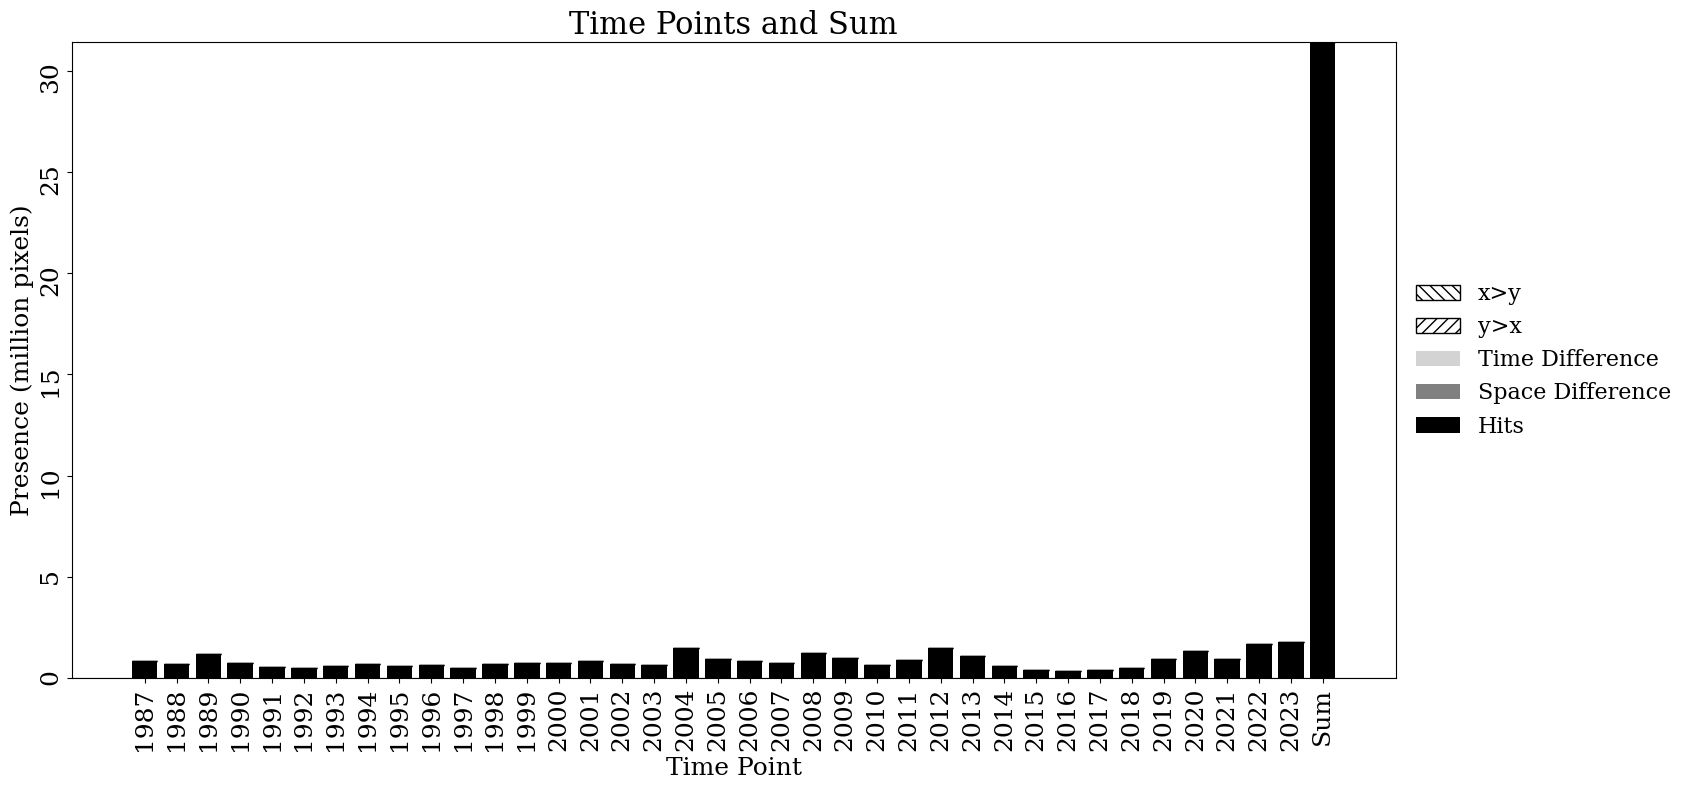


✅ Processing complete. Graphic saved as: C:\Users\AntFonseca\github\2.OUTPUT\def\presence_agreement_def.png


In [13]:
# =============================================================================
# 1. Making the graphic
# =============================================================================
print("\nMaking the graphic...")

mpl.rcParams['font.family'] = 'serif'

# ----------------------------------------------------------------------------- 
# 1.2 Data preparation
# -----------------------------------------------------------------------------
labels = [str(tp) for tp in time_points] + ["Sum"]

hits = [
    results_by_time.get(tp, {}).get("Hit", 0)
    for tp in time_points
] + [sum_results["Hit"]]

space_diff = [
    results_by_time.get(tp, {}).get("Space Difference", 0)
    for tp in time_points
] + [sum_results["Space Difference"]]

time_diff = [0] * len(time_points) + [sum_results["Time Difference"]]

misses = [
    results_by_time.get(tp, {}).get("Miss", 0)
    for tp in time_points
] + [sum_results["Miss"]]

false_alarms = [
    results_by_time.get(tp, {}).get("False Alarm", 0)
    for tp in time_points
] + [sum_results["False Alarm"]]

# ----------------------------------------------------------------------------- 
# 1.3 Figure setup
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(figsize=(20, 8))

bottom = np.zeros(len(labels))

ax.axhline(
    0,
    color="black",
    linewidth=0.8
)

# ----------------------------------------------------------------------------- 
# 1.4 Bars
# -----------------------------------------------------------------------------
ax.bar(
    labels,
    hits,
    label="Hits",
    color="black",
    bottom=bottom
)
bottom += np.array(hits)

ax.bar(
    labels,
    space_diff,
    label="Space Difference",
    color="grey",
    bottom=bottom
)
bottom += np.array(space_diff)

ax.bar(
    labels,
    time_diff,
    label="Time Difference",
    color="lightgray",
    bottom=bottom
)
bottom += np.array(time_diff)

ax.bar(
    labels,
    misses,
    label="x>y",
    color="white",
    edgecolor="black",
    hatch="\\\\\\",
    bottom=bottom
)
bottom += np.array(misses)

ax.bar(
    labels,
    false_alarms,
    label="y>x",
    color="white",
    edgecolor="black",
    hatch="///",
    bottom=bottom
)

# ----------------------------------------------------------------------------- 
# 1.5 Legend Settings
# -----------------------------------------------------------------------------
handles, labels_list = ax.get_legend_handles_labels()

order = [
    "x>y",
    "y>x",
    "Time Difference",
    "Space Difference",
    "Hits"
]

legend_dict = dict(zip(labels_list, handles))

ordered_handles = [legend_dict[label] for label in order]

ax.legend(
    ordered_handles,
    order,
    loc="center left",
    fontsize=16,
    bbox_to_anchor=(1, 0.5),
    frameon=False
)

# ----------------------------------------------------------------------------- 
# 1.6 Axes labels and title
# -----------------------------------------------------------------------------
ax.set_title(
    "Time Points and Sum",
    fontsize=22
)

ax.set_xlabel(
    "Time Point",
    fontsize=18
)

ax.tick_params(
    axis="both",
    which="major",
    labelsize=18,
    rotation=90
)

# =============================================================================
# --- y-axis scale settings (choose one option) ---
# =============================================================================

# Option 1: For 'toy_data' or data with small values
# ax.set_ylim(
#     0,
#     18
# )
# ax.set_ylabel(
#     "Presence",
#     fontsize=18
# )

# Option 2: For large values (divide by 1 million)
def millions_formatter(y, pos):
    return f"{y / 1_000_000:.0f}"

ax.yaxis.set_major_formatter(
    FuncFormatter(millions_formatter)
)
ax.set_ylabel(
    "Presence (million pixels)",
    fontsize=18
)

# ax.set_ylim(
#     0,
#     45_000_000
# )

# Option 3: For large values (divide by 1 thousand)
# def thousands_formatter(y, pos):
#     return f"{y / 1_000:.0f}"

# ax.yaxis.set_major_formatter(
#     FuncFormatter(thousands_formatter)
# )
# ax.set_ylabel(
#     "Presence",
#     fontsize=18
# )

# =============================================================================
# 1.7 Save figure
# =============================================================================
plt.tight_layout(rect=[0, 0, 0.85, 1])

output_filename = f"presence_agreement_{class_name}.png"
final_chart_path = os.path.join(output_path, output_filename)

plt.savefig(
    final_chart_path,
    dpi=300
)

plt.show()

print(f"\n✅ Processing complete. Graphic saved as: {final_chart_path}")

#### 4.2 Gross Change


Making the graphic...


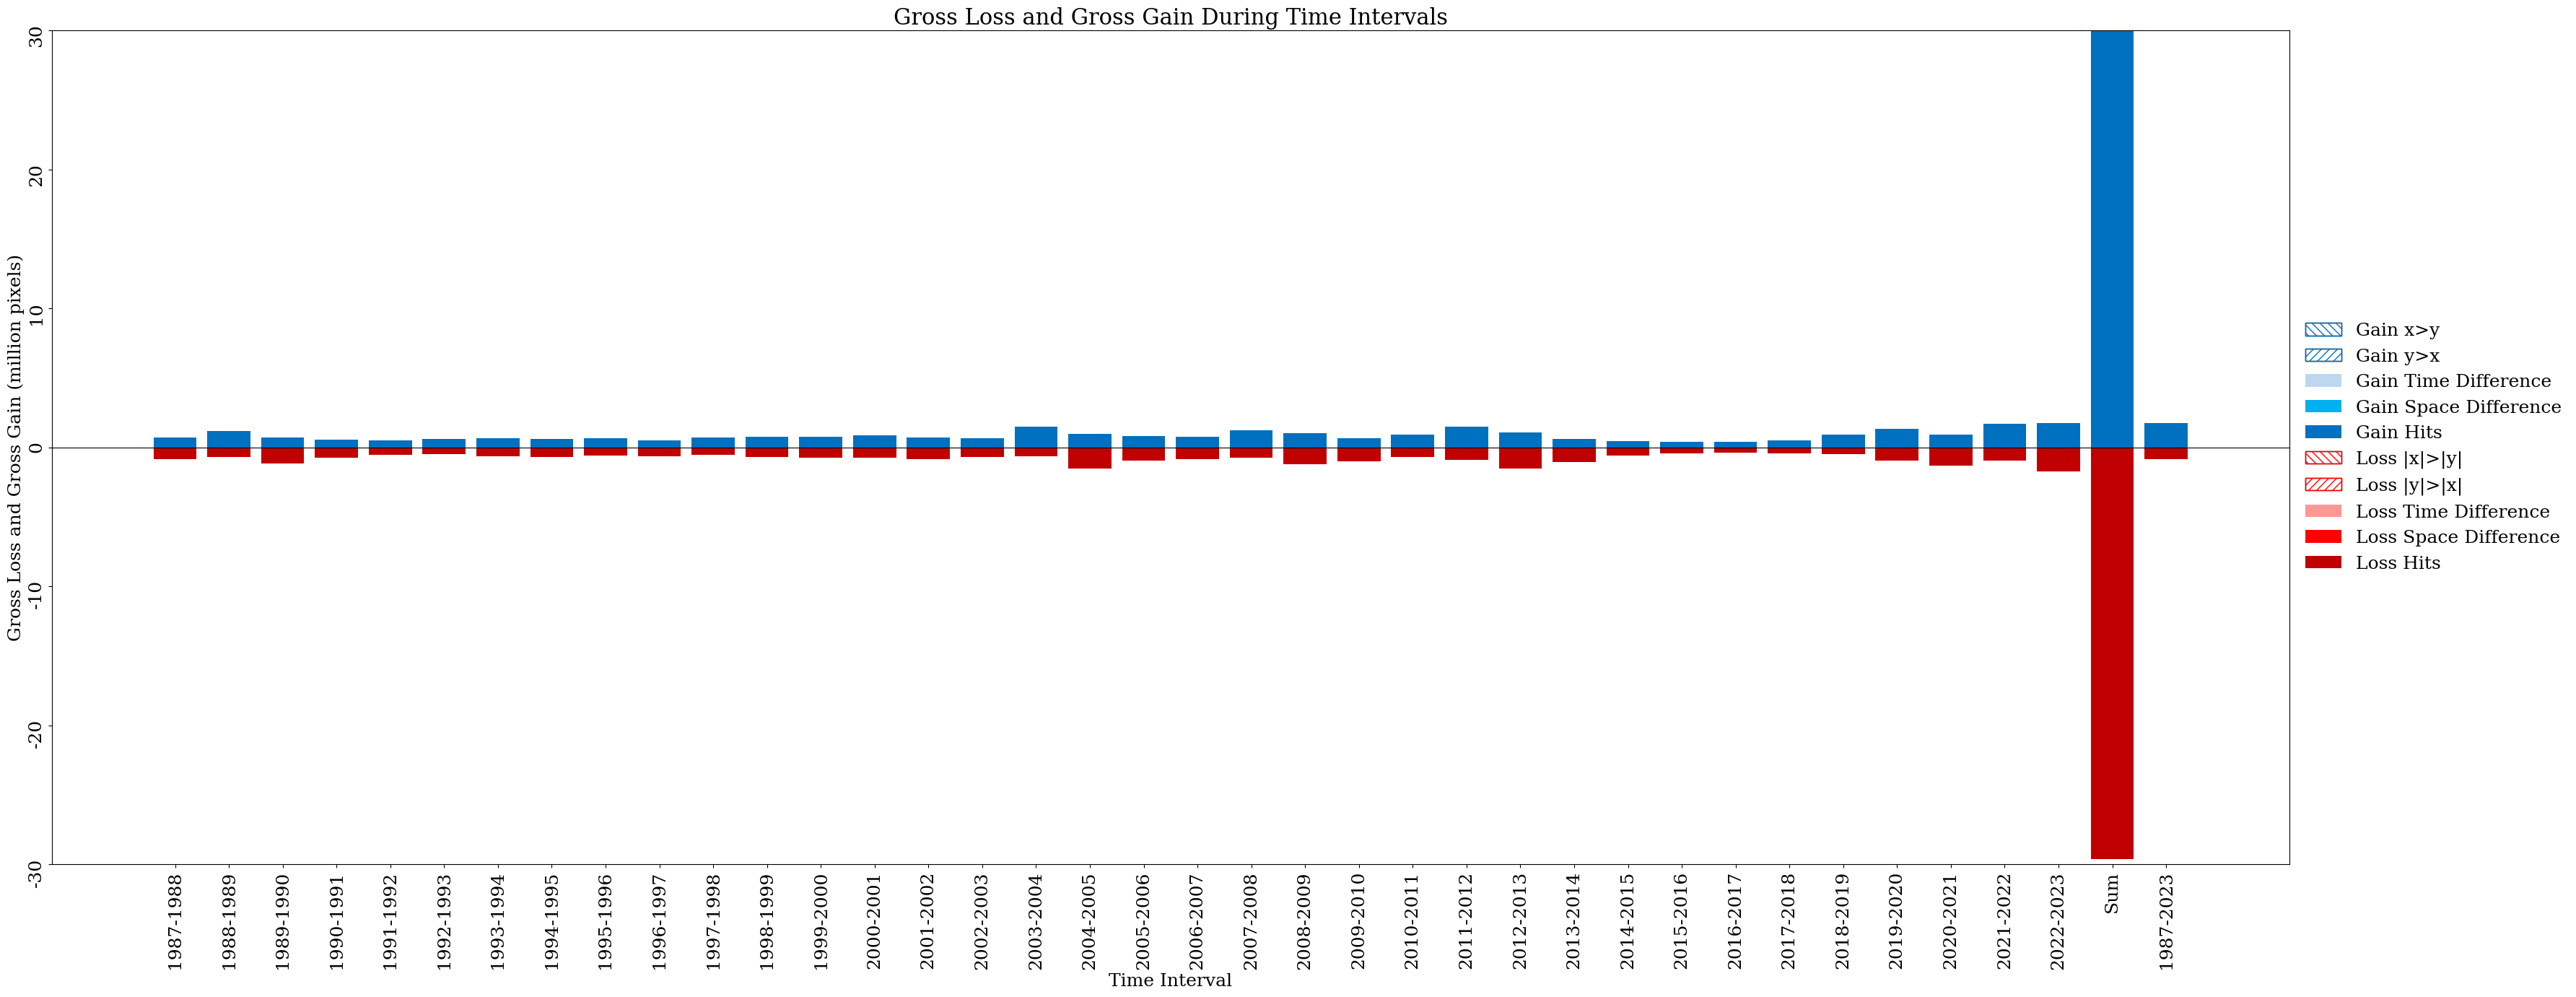


✅ Processing complete. Graphic saved as: C:\Users\AntFonseca\github\2.OUTPUT\def\gross_change_def.png


In [18]:
# =============================================================================
# 1. Making the graphic
# =============================================================================
print("\nMaking the graphic...")

mpl.rcParams["font.family"] = "serif"

# -----------------------------------------------------------------------------
# 1.2 Data preparation
# -----------------------------------------------------------------------------
plot_data_list = []

for interval in time_intervals:
    row_data = change_results_by_interval.get(interval, {})
    row_data["Interval"] = interval
    plot_data_list.append(row_data)

sum_row_gross = sum_change_results.copy()
sum_row_gross["Interval"] = "Sum"
plot_data_list.append(sum_row_gross)

extent_row_gross = extent_results.copy()
extent_row_gross["Interval"] = f"{time_points[0]}-{time_points[-1]}"
plot_data_list.append(extent_row_gross)

df_plot = pd.DataFrame(plot_data_list).set_index("Interval").fillna(0)
labels = df_plot.index.tolist()

gain_colors = {
    "Hits": "#0070C0",
    "Space Difference": "#00B0F0",
    "Time Difference": "#BDD7EE",
    "Miss": "white",
    "False Alarm": "white"
}
loss_colors = {
    "Hits": "#C00000",
    "Space Difference": "#FF0000",
    "Time Difference": "#FF9696",
    "Miss": "white",
    "False Alarm": "white"
}
gain_hatch_color = "#0070C0"
loss_hatch_color = "#FF0000"

# -----------------------------------------------------------------------------
# 1.3 Figure setup
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(40, 15)
)

ax.axhline(
    0,
    color="black",
    linewidth=0.8
)

# -----------------------------------------------------------------------------
# 1.4 Bars — Gains
# -----------------------------------------------------------------------------
bottom_gain = np.zeros(len(labels))

for comp in ["Hits", "Space Difference", "Time Difference", "Miss", "False Alarm"]:
    disp = "x>y" if comp == "Miss" else ("y>x" if comp == "False Alarm" else comp)
    col = f"Gain {comp}"
    data = df_plot[col].values

    if comp in ["Miss", "False Alarm"]:
        plot_data = data.astype(float)
        plot_data[plot_data == 0] = np.nan
        hatch = "///" if comp == "False Alarm" else "\\\\\\"

        ax.bar(
            labels,
            plot_data,
            label=f"Gain {disp}",
            color="white",
            bottom=bottom_gain,
            edgecolor="black"
        )
        ax.bar(
            labels,
            plot_data,
            color="none",
            bottom=bottom_gain,
            edgecolor=gain_hatch_color,
            hatch=hatch
        )
    else:
        ax.bar(
            labels,
            data,
            label=f"Gain {disp}",
            color=gain_colors[comp],
            bottom=bottom_gain,
            edgecolor="none"
        )
    bottom_gain += data

# -----------------------------------------------------------------------------
# 1.5 Bars — Losses
# -----------------------------------------------------------------------------
bottom_loss = np.zeros(len(labels))

for comp in ["Hits", "Space Difference", "Time Difference", "Miss", "False Alarm"]:
    disp = "|x|>|y|" if comp == "Miss" else ("|y|>|x|" if comp == "False Alarm" else comp)
    col = f"Loss {comp}"
    data = df_plot[col].values

    if comp in ["Miss", "False Alarm"]:
        plot_data = data.astype(float)
        plot_data[plot_data == 0] = np.nan
        hatch = "///" if comp == "False Alarm" else "\\\\\\"

        ax.bar(
            labels,
            plot_data,
            label=f"Loss {disp}",
            color="white",
            bottom=bottom_loss,
            edgecolor="black"
        )
        ax.bar(
            labels,
            plot_data,
            color="none",
            bottom=bottom_loss,
            edgecolor=loss_hatch_color,
            hatch=hatch
        )
    else:
        ax.bar(
            labels,
            data,
            label=f"Loss {disp}",
            color=loss_colors[comp],
            bottom=bottom_loss,
            edgecolor="none"
        )
    bottom_loss += data

# -----------------------------------------------------------------------------
# 1.6 Legend Settings
# -----------------------------------------------------------------------------
handles, labels_list = ax.get_legend_handles_labels()
legend_dict = dict(zip(labels_list, handles))

legend_dict["Gain x>y"] = (
    mpatches.Patch(facecolor="white", edgecolor="black"),
    mpatches.Patch(facecolor="none", edgecolor=gain_hatch_color, hatch="\\\\\\")
)
legend_dict["Gain y>x"] = (
    mpatches.Patch(facecolor="white", edgecolor="black"),
    mpatches.Patch(facecolor="none", edgecolor=gain_hatch_color, hatch="///")
)
legend_dict["Loss |x|>|y|"] = (
    mpatches.Patch(facecolor="white", edgecolor="black"),
    mpatches.Patch(facecolor="none", edgecolor=loss_hatch_color, hatch="\\\\\\")
)
legend_dict["Loss |y|>|x|"] = (
    mpatches.Patch(facecolor="white", edgecolor="black"),
    mpatches.Patch(facecolor="none", edgecolor=loss_hatch_color, hatch="///")
)

order = [
    "Gain x>y",
    "Gain y>x",
    "Gain Time Difference",
    "Gain Space Difference",
    "Gain Hits",
    "Loss |x|>|y|",
    "Loss |y|>|x|",
    "Loss Time Difference",
    "Loss Space Difference",
    "Loss Hits"
]

ordered_handles = [legend_dict.get(label) for label in order if label in legend_dict]
ordered_labels  = [label for label in order if label in legend_dict]

ax.legend(
    handles=ordered_handles,
    labels=ordered_labels,
    loc="center left",
    fontsize=18,
    bbox_to_anchor=(1, 0.5),
    frameon=False,
    alignment="left"
)

# -----------------------------------------------------------------------------
# 1.7 Axes labels and title
# -----------------------------------------------------------------------------
ax.set_title(
    "Gross Loss and Gross Gain During Time Intervals",
    fontsize=22
)
ax.set_xlabel(
    "Time Interval",
    fontsize=18
)
ax.tick_params(
    axis="both",
    which="major",
    labelsize=18,
    rotation=90
)

# =============================================================================
# --- y-axis scale settings (choose one option) ---
# =============================================================================

# Option 1: For 'toy_data' or data with small values
# ax.autoscale(enable=False, axis="y")
# ax.set_ylim(-8, 14)
# ax.margins(y=0)
# ax.set_yticks(np.arange(-8, 14 + 1, 2))
# ax.set_ylabel(
#     "Gross Loss and Gross Gain (million pixels)",
#     fontsize=18
# )

# Option 2: For large values (divide by 1 million)
def millions_formatter(y, pos):
    return f"{y / 1_000_000:.0f}"
ax.yaxis.set_major_formatter(FuncFormatter(millions_formatter))
ax.set_ylim(-30_000_000, 30_000_000)
ax.set_ylabel(
    "Gross Loss and Gross Gain (million pixels)",
    fontsize=18
)

# Option 3: For large values (divide by 1 thousand)
# def thousands_formatter(y, pos):
#     return f"{y / 1_000:.0f}"
# ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
# ax.set_ylim(-900_000, 900_000)
# ax.set_ylabel(
#     "Gross Loss and Gross Gain (thousand pixels)",
#     fontsize=20
# )

# =============================================================================
# 1.8 Save figure
# =============================================================================
output_filename = f"gross_change_{class_name}.png"
final_path = os.path.join(output_path, output_filename)

plt.savefig(
    final_path,
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print(f"\n✅ Processing complete. Graphic saved as: {final_path}")


#### 4.3 Net Change


Making the graphic...


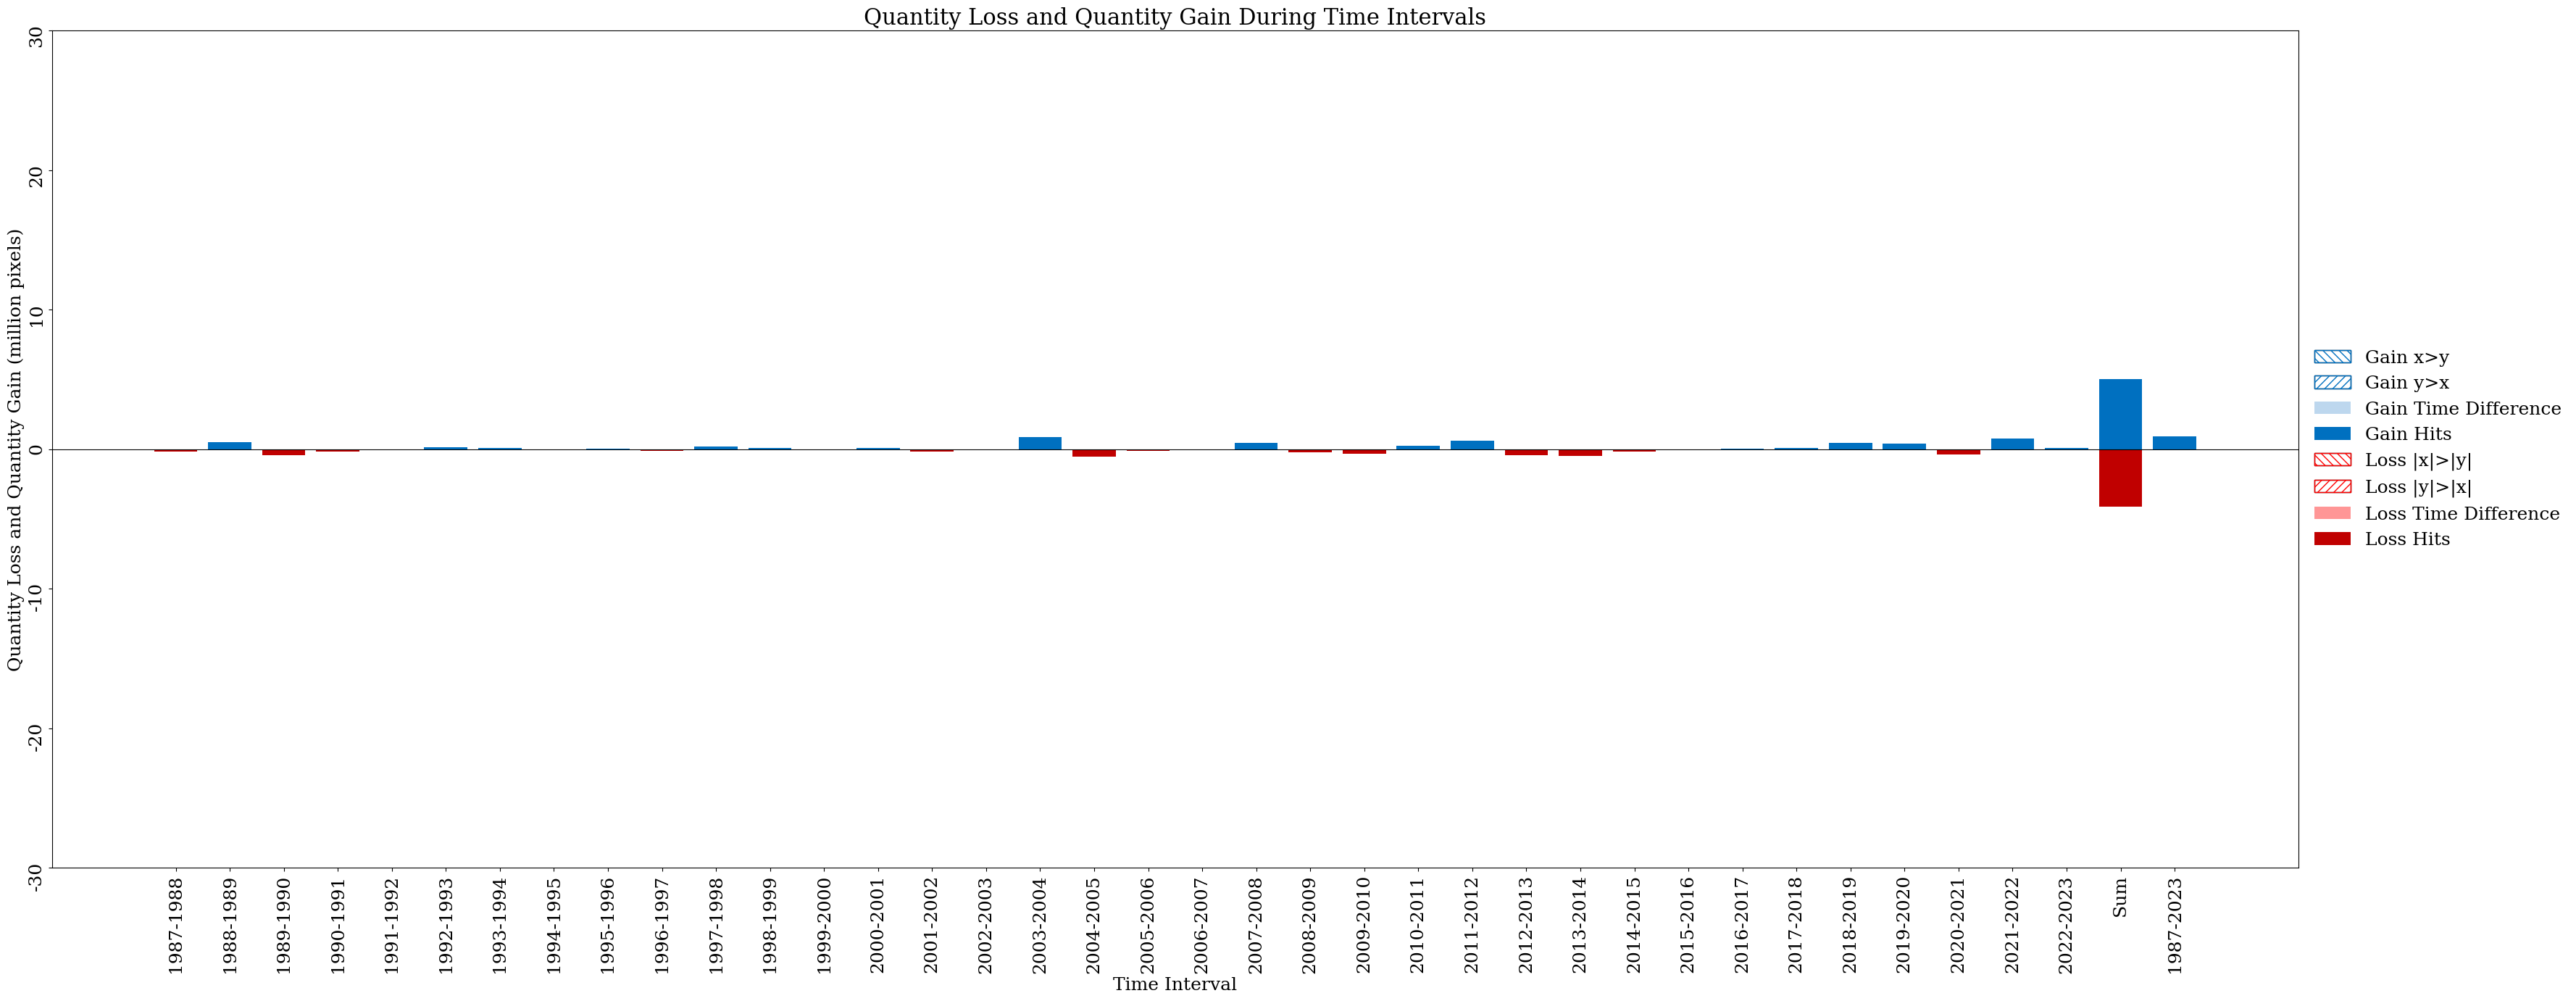


✅ Processing complete. Graphic saved as: C:\Users\AntFonseca\github\2.OUTPUT\def\net_change_def.png


In [19]:
# =============================================================================
# 1. Making the graphic
# =============================================================================
print("\nMaking the graphic...")

mpl.rcParams["font.family"] = "serif"

# -----------------------------------------------------------------------------
# 1.2 Data preparation
# -----------------------------------------------------------------------------
net_plot_data_list = []

for interval in time_intervals:
    row_data = net_change_by_interval.get(interval, {})
    row_data["Interval"] = interval
    net_plot_data_list.append(row_data)

sum_row_net = sum_net_results.copy()
sum_row_net["Interval"] = "Sum"
net_plot_data_list.append(sum_row_net)

extent_row_net = net_extent_results.copy()
extent_row_net["Interval"] = f"{time_points[0]}-{time_points[-1]}"
net_plot_data_list.append(extent_row_net)

df_plot_net = pd.DataFrame(net_plot_data_list).set_index("Interval").fillna(0)
labels = df_plot_net.index.tolist()

gain_colors = {
    "Hits": "#0070C0",
    "Time Difference": "#BDD7EE",
    "Miss": "white",
    "False Alarm": "white"
}
loss_colors = {
    "Hits": "#C00000",
    "Time Difference": "#FF9696",
    "Miss": "white",
    "False Alarm": "white"
}
gain_hatch_color = "#0070C0"
loss_hatch_color = "#FF0000"

# -----------------------------------------------------------------------------
# 1.3 Figure setup
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(40, 15)
)

ax.axhline(
    0,
    color="black",
    linewidth=0.8
)

# -----------------------------------------------------------------------------
# 1.4 Bars — Net Gains
# -----------------------------------------------------------------------------
bottom_gain = np.zeros(len(labels))

for comp in ["Hits", "Time Difference", "Miss", "False Alarm"]:
    # final legend text (no post-remap needed)
    disp = (
        "x>y" if comp == "Miss"
        else ("y>x" if comp == "False Alarm" else comp)
    )

    data = df_plot_net[f"Gain {comp}"].values

    if comp in ["Miss", "False Alarm"]:
        plot_data = data.astype(float)
        plot_data[plot_data == 0] = np.nan
        hatch = "///" if comp == "False Alarm" else "\\\\\\"

        ax.bar(
            labels,
            plot_data,
            label=f"Gain {disp}",
            color="white",
            bottom=bottom_gain,
            edgecolor="black"
        )
        ax.bar(
            labels,
            plot_data,
            color="none",
            bottom=bottom_gain,
            edgecolor=gain_hatch_color,
            hatch=hatch
        )
    else:
        ax.bar(
            labels,
            data,
            label=f"Gain {disp}",
            color=gain_colors[comp],
            bottom=bottom_gain,
            edgecolor="none"
        )
    bottom_gain += data

# -----------------------------------------------------------------------------
# 1.5 Bars — Net Losses
# -----------------------------------------------------------------------------
bottom_loss = np.zeros(len(labels))

for comp in ["Hits", "Time Difference", "Miss", "False Alarm"]:
    # final legend text (no post-remap needed)
    disp = (
        "|x|>|y|" if comp == "Miss"
        else ("|y|>|x|" if comp == "False Alarm" else comp)
    )

    data = df_plot_net[f"Loss {comp}"].values

    if comp in ["Miss", "False Alarm"]:
        plot_data = data.astype(float)
        plot_data[plot_data == 0] = np.nan
        hatch = "///" if comp == "False Alarm" else "\\\\\\"

        ax.bar(
            labels,
            plot_data,
            label=f"Loss {disp}",
            color="white",
            bottom=bottom_loss,
            edgecolor="black"
        )
        ax.bar(
            labels,
            plot_data,
            color="none",
            bottom=bottom_loss,
            edgecolor=loss_hatch_color,
            hatch=hatch
        )
    else:
        ax.bar(
            labels,
            data,
            label=f"Loss {disp}",
            color=loss_colors[comp],
            bottom=bottom_loss,
            edgecolor="none"
        )
    bottom_loss += data

# -----------------------------------------------------------------------------
# 1.6 Legend Settings
# -----------------------------------------------------------------------------
handles, labels_list = ax.get_legend_handles_labels()
legend_dict = dict(zip(labels_list, handles))

# custom patches for hatched entries
legend_dict["Gain x>y"] = (
    mpatches.Patch(facecolor="white", edgecolor="black"),
    mpatches.Patch(facecolor="none", edgecolor=gain_hatch_color, hatch="\\\\\\")
)
legend_dict["Gain y>x"] = (
    mpatches.Patch(facecolor="white", edgecolor="black"),
    mpatches.Patch(facecolor="none", edgecolor=gain_hatch_color, hatch="///")
)
legend_dict["Loss |x|>|y|"] = (
    mpatches.Patch(facecolor="white", edgecolor="black"),
    mpatches.Patch(facecolor="none", edgecolor=loss_hatch_color, hatch="\\\\\\")
)
legend_dict["Loss |y|>|x|"] = (
    mpatches.Patch(facecolor="white", edgecolor="black"),
    mpatches.Patch(facecolor="none", edgecolor=loss_hatch_color, hatch="///")
)

order = [
    "Gain x>y",
    "Gain y>x",
    "Gain Time Difference",
    "Gain Hits",
    "Loss |x|>|y|",
    "Loss |y|>|x|",
    "Loss Time Difference",
    "Loss Hits"
]

ordered_handles = [legend_dict.get(label) for label in order if label in legend_dict]
ordered_labels  = [label for label in order if label in legend_dict]

ax.legend(
    handles=ordered_handles,
    labels=ordered_labels,
    loc="center left",
    fontsize=18,
    bbox_to_anchor=(1, 0.5),
    frameon=False,
    alignment="left"
)

# -----------------------------------------------------------------------------
# 1.7 Axes labels and title
# -----------------------------------------------------------------------------
ax.set_title(
    "Quantity Loss and Quantity Gain During Time Intervals",
    fontsize=22
)
ax.set_xlabel(
    "Time Interval",
    fontsize=18
)
ax.tick_params(
    axis="both",
    which="major",
    labelsize=18,
    rotation=90
)

# =============================================================================
# --- y-axis scale settings (choose one option) ---
# =============================================================================

# Option 1: For 'toy_data' or data with small values
# ax.autoscale(enable=False, axis="y")
# ax.set_ylim(-8, 14)
# ax.margins(y=0)
# ax.set_yticks(np.arange(-8, 14 + 1, 2))
# ax.set_ylabel(
#     "Quantity Loss and Quantity Gain (million pixels)",
#     fontsize=18
# )

# Option 2: For real data with large values
def millions_formatter(y, pos):
    return f"{y / 1_000_000:.0f}"

ax.yaxis.set_major_formatter(FuncFormatter(millions_formatter))
ax.set_ylim(-30_000_000, 30_000_000)
ax.set_ylabel(
    "Quantity Loss and Quantity Gain (million pixels)",
    fontsize=18
)

# Option 3: For real data with large values (thousand)
# def thousands_formatter(y, pos):
#     return f"{y / 1_000:.0f}"
# ax.yaxis.set_major_formatter(FuncFormatter(thousands_formatter))
# ax.set_ylim(-900_000, 900_000)
# ax.set_ylabel(
#     "Quantity Loss and Quantity Gain (thousand pixels)",
#     fontsize=20
# )

# =============================================================================
# 1.8 Save figure
# =============================================================================
output_filename = f"net_change_{class_name}.png"
final_path = os.path.join(output_path, output_filename)

plt.savefig(
    final_path,
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print(f"\n✅ Processing complete. Graphic saved as: {final_path}")


## 5. Export results

In [20]:
# =============================================================================
# 1. Export all graphic results to an Excel file
# =============================================================================
print("Starting the export of results to Excel...")

import pandas as pd

excel_filename = f"analysis_results_{class_name}.xlsx"
excel_final_path = os.path.join(
    output_path,
    excel_filename
)

with pd.ExcelWriter(excel_final_path, engine="xlsxwriter") as writer:

    # -----------------------------------------------------------------------------
    # ReadMe sheet
    # -----------------------------------------------------------------------------
    readme_text = (
        "This Excel file summarizes all results from the notebook.\n\n"
        "Sheet descriptions:\n\n"
        "- Presence Agreement:\n"
        "  Aggregated values for the Presence Agreement chart (Hits, Misses, etc.)\n"
        "  for each time point and the final sum.\n\n"
        "- Gross Change:\n"
        "  Values for the Gross Loss and Gain chart, showing all components of gross\n"
        "  change (including Space Difference) for each interval, the sum, and extent.\n\n"
        "- Net Change:\n"
        "  Values for the Net Change chart, showing quantity-based components of change\n"
        "  (without Space Difference) for each interval, the sum, and the extent."
    )
    df_readme = pd.DataFrame(
        {"File Description": [readme_text]}
    )
    df_readme.to_excel(
        writer,
        sheet_name="ReadMe",
        index=False
    )

    # -----------------------------------------------------------------------------
    # Presence Agreement sheet
    # -----------------------------------------------------------------------------
    presence_data_list = []

    for tp in time_points:
        row_data = results_by_time.get(tp, {})
        row_data["Time Point"] = tp
        presence_data_list.append(row_data)

    sum_row_presence = sum_results.copy()
    sum_row_presence["Time Point"] = "Sum"
    presence_data_list.append(sum_row_presence)

    df_presence = pd.DataFrame(presence_data_list)

    presence_cols_order = [
        "Time Point",
        "Hit",
        "Space Difference",
        "Time Difference",
        "Miss",
        "False Alarm",
        "Total X",
        "Total Y"
    ]
    df_presence = (
        df_presence[presence_cols_order]
        .fillna(0)
    )

    df_presence.to_excel(
        writer,
        sheet_name="Presence Agreement",
        index=False
    )

    # -----------------------------------------------------------------------------
    # Gross Change sheet
    # -----------------------------------------------------------------------------
    gross_change_data_list = []

    for interval in time_intervals:
        row_data = change_results_by_interval.get(interval, {})
        row_data["Interval"] = interval
        gross_change_data_list.append(row_data)

    sum_row_gross = sum_change_results.copy()
    sum_row_gross["Interval"] = "Sum"
    gross_change_data_list.append(sum_row_gross)

    extent_row_gross = extent_results.copy()
    extent_row_gross["Interval"] = f"{time_points[0]}-{time_points[-1]}"
    gross_change_data_list.append(extent_row_gross)

    df_gross = pd.DataFrame(gross_change_data_list)

    gross_cols_order = [
        "Interval",
        "Gain Hits",
        "Gain Space Difference",
        "Gain Time Difference",
        "Gain Miss",
        "Gain False Alarm",
        "Loss Hits",
        "Loss Space Difference",
        "Loss Time Difference",
        "Loss Miss",
        "Loss False Alarm"
    ]
    df_gross = (
        df_gross[gross_cols_order]
        .fillna(0)
    )

    df_gross.to_excel(
        writer,
        sheet_name="Gross Change",
        index=False
    )

    # -----------------------------------------------------------------------------
    # Net Change sheet
    # -----------------------------------------------------------------------------
    net_change_data_list = []

    for interval in time_intervals:
        row_data = net_change_by_interval.get(interval, {})
        row_data["Interval"] = interval
        net_change_data_list.append(row_data)

    sum_row_net = sum_net_results.copy()
    sum_row_net["Interval"] = "Sum"
    net_change_data_list.append(sum_row_net)

    extent_row_net = net_extent_results.copy()
    extent_row_net["Interval"] = f"{time_points[0]}-{time_points[-1]}"
    net_change_data_list.append(extent_row_net)

    df_net = pd.DataFrame(net_change_data_list)

    net_cols_order = [
        "Interval",
        "Gain Hits",
        "Gain Time Difference",
        "Gain Miss",
        "Gain False Alarm",
        "Loss Hits",
        "Loss Time Difference",
        "Loss Miss",
        "Loss False Alarm"
    ]
    df_net = (
        df_net[net_cols_order]
        .fillna(0)
    )

    df_net.to_excel(
        writer,
        sheet_name="Net Change",
        index=False
    )

    # -----------------------------------------------------------------------------
    # Auto-adjust column widths
    # -----------------------------------------------------------------------------
    workbook = writer.book

    for sheet_name, df in {
        "ReadMe": df_readme,
        "Presence Agreement": df_presence,
        "Gross Change": df_gross,
        "Net Change": df_net
    }.items():

        worksheet = writer.sheets[sheet_name]

        if sheet_name == "ReadMe":
            worksheet.set_column("A:A", 80)
            cell_format = workbook.add_format(
                {"valign": "top", "text_wrap": True}
            )
            worksheet.set_row(0, 150, cell_format)
        else:
            for idx, col in enumerate(df.columns):
                series = df[col].astype(str)
                max_len = max(series.map(len).max(), len(str(col))) + 2
                worksheet.set_column(idx, idx, max_len)

print(f"\n✅ All results successfully exported to: {excel_final_path}")

Starting the export of results to Excel...

✅ All results successfully exported to: C:\Users\AntFonseca\github\2.OUTPUT\def\analysis_results_def.xlsx


# 6. Maps

## 6.1 Presence Hit

### 6.1.1 Calcule Presence Hit Map

In [ ]:
# =============================================================================
# 1. Calculate and save Presence Hits map
# =============================================================================
print("\nStarting calculation for Presence Hits map...")

# -----------------------------------------------------------------------------
# 1.1 Initialize accumulator map
# -----------------------------------------------------------------------------
first_year = time_points[0]
first_file_name = f"{class_name}{first_year}.tif"
path_to_first_file = os.path.join(
    path_series_x,
    first_file_name
)

try:
    with rasterio.open(path_to_first_file) as src:
        profile = src.profile
        height  = src.height
        width   = src.width

        # float32 supports long series and continuous sums
        An_map = np.zeros(
            (height, width),
            dtype=np.float32
        )
        print(
            f"Accumulator map initialized with dimensions: "
            f"{height} x {width}."
        )
except FileNotFoundError:
    print(
        f"ERROR: Reference file not found: {path_to_first_file}"
    )
    An_map = None

# -----------------------------------------------------------------------------
# 1.2 Accumulate presence hits across time points
# -----------------------------------------------------------------------------
if An_map is not None:
    print("\nComputing per-pixel values for each time point...")

    # Track pixels that were never valid in the entire series
    final_nodata_mask = np.ones_like(
        An_map,
        dtype=bool
    )

    for year in time_points:
        file_name = f"{class_name}{year}.tif"

        path_x = os.path.join(
            path_series_x,
            file_name
        )
        path_y = os.path.join(
            path_series_y,
            file_name
        )

        if os.path.exists(path_x) and os.path.exists(path_y):
            print(f"Processing: {file_name}...")
            with rasterio.open(path_x) as src_x, rasterio.open(path_y) as src_y:
                ax = src_x.read(1)
                ay = src_y.read(1)

                # Valid where neither input is NoData
                valid_mask = (
                    (ax != nodata_value) &
                    (ay != nodata_value)
                )

                if is_binary_data:
                    # Binary presence: count a hit only when both are 1
                    x1 = (ax == 1)
                    y1 = (ay == 1)
                    Phtn_map = (x1 & y1).astype(np.float32)
                else:
                    # Continuous presence: hit = min(x, y)
                    Phtn_map = np.minimum(
                        ax.astype(np.float32),
                        ay.astype(np.float32)
                    )

                # Accumulate only over valid pixels
                np.add(
                    An_map,
                    Phtn_map,
                    out=An_map,
                    where=valid_mask
                )

                # Update the "never valid" mask
                final_nodata_mask &= ~valid_mask
        else:
            print(
                f"Warning: Missing files for year {year}. Skipping."
            )

    # Mark pixels that were never valid as NoData
    An_map[final_nodata_mask] = nodata_value
    print("\n✅ Pixel-wise accumulation complete.")

# -----------------------------------------------------------------------------
# 1.3 Save raster
# -----------------------------------------------------------------------------
if An_map is not None:
    profile.update(
        dtype=rasterio.float32,
        nodata=nodata_value,
        compress="lzw"
    )

    output_filename_map = f"presence_hit_{class_name}.tif"
    final_map_path = os.path.join(
        output_path,
        output_filename_map
    )

    print(f"\nSaving final map to: {final_map_path}")
    with rasterio.open(final_map_path, "w", **profile) as dst:
        dst.write(An_map, 1)

    print("✅ Presence Hits map saved successfully.")

In [ ]:
# =============================================================================
# 1. Calculate and save Presence Hits map
# =============================================================================
print("\nStarting calculation for Presence Hits map...")

# -----------------------------------------------------------------------------
# 1.1 Initialize accumulator map
# -----------------------------------------------------------------------------
first_year = time_points[0]
first_file_name = f"{class_name}{first_year}.tif"
path_to_first_file = os.path.join(
    path_series_x,
    first_file_name
)

try:
    with rasterio.open(path_to_first_file) as src:
        profile = src.profile
        height  = src.height
        width   = src.width

        # float32 supports long series and continuous sums
        An_map = np.zeros(
            (height, width),
            dtype=np.float32
        )
        print(
            f"Accumulator map initialized with dimensions: "
            f"{height} x {width}."
        )
except FileNotFoundError:
    print(
        f"ERROR: Reference file not found: {path_to_first_file}"
    )
    An_map = None

# -----------------------------------------------------------------------------
# 1.2 Accumulate presence hits across time points
# -----------------------------------------------------------------------------
if An_map is not None:
    print("\nComputing per-pixel values for each time point...")

    # Track pixels that were never valid in the entire series
    final_nodata_mask = np.ones_like(
        An_map,
        dtype=bool
    )

    for year in time_points:
        file_name = f"{class_name}{year}.tif"

        path_x = os.path.join(
            path_series_x,
            file_name
        )
        path_y = os.path.join(
            path_series_y,
            file_name
        )

        if os.path.exists(path_x) and os.path.exists(path_y):
            print(f"Processing: {file_name}...")
            with rasterio.open(path_x) as src_x, rasterio.open(path_y) as src_y:
                ax = src_x.read(1)
                ay = src_y.read(1)

                # Dataset masks (valid pixels per file)
                mx = src_x.read_masks(1) != 0
                my = src_y.read_masks(1) != 0

                # Valid where both inputs are valid and not our nodata_value.
                # IMPORTANT: 0 is a VALID value; do NOT treat src.nodata==0 as NoData.
                valid_mask = (
                    mx & my &
                    ~(np.isnan(ax) | np.isnan(ay)) &
                    (ax != nodata_value) & (ay != nodata_value)
                )

                if is_binary_data:
                    # Binary presence: count a hit only when both are 1
                    x1 = (ax == 1)
                    y1 = (ay == 1)
                    Phtn_map = (x1 & y1).astype(np.float32)
                else:
                    # Continuous presence: enforce non-negativity, then hit = min(x, y)
                    ax_pos = np.maximum(ax.astype(np.float32), 0.0)
                    ay_pos = np.maximum(ay.astype(np.float32), 0.0)
                    Phtn_map = np.minimum(ax_pos, ay_pos)

                # Accumulate only over valid pixels
                np.add(
                    An_map,
                    Phtn_map,
                    out=An_map,
                    where=valid_mask
                )

                # Update the "never valid" mask
                final_nodata_mask &= ~valid_mask
        else:
            print(
                f"Warning: Missing files for year {year}. Skipping."
            )

    # Mark pixels that were never valid as NoData
    An_map[final_nodata_mask] = nodata_value
    print("\n✅ Pixel-wise accumulation complete.")

# -----------------------------------------------------------------------------
# 1.3 Save raster
# -----------------------------------------------------------------------------
if An_map is not None:
    profile.update(
        dtype=rasterio.float32,
        nodata=nodata_value,
        compress="lzw"
    )

    output_filename_map = f"presence_hit_{class_name}.tif"
    final_map_path = os.path.join(
        output_path,
        output_filename_map
    )

    print(f"\nSaving final map to: {final_map_path}")
    with rasterio.open(final_map_path, "w", **profile) as dst:
        dst.write(An_map, 1)

    print("✅ Presence Hits map saved successfully.")

### 6.1.2 Plot Presence Hit Map

In [ ]:
# =============================================================================
# 1. Making the graphic
# =============================================================================
print("\nMaking the Presence Hits map...")

mpl.rcParams["font.family"] = "serif"

# -----------------------------------------------------------------------------
# 1.1 Data preparation
# -----------------------------------------------------------------------------
input_map_filename = f"presence_hit_{class_name}.tif"
input_map_path = os.path.join(
    output_path,
    input_map_filename
)

scale_factor = 0.15

with rasterio.open(input_map_path) as src:
    bounds = src.bounds
    src_crs = src.crs

    transformer = Transformer.from_crs(
        src_crs,
        "EPSG:4326",
        always_xy=True
    )

    data = src.read(
        1,
        out_shape=(
            int(src.height * scale_factor),
            int(src.width * scale_factor)
        ),
        resampling=Resampling.nearest
    )

masked_map = np.ma.masked_equal(
    data,
    nodata_value
)

# -----------------------------------------------------------------------------
# 1.2 Colormap
# -----------------------------------------------------------------------------
num_time_points = len(time_points)

if is_binary_data:
    nT = num_time_points
    boundaries = np.arange(-0.5, nT + 1.5, 1.0)

    vir = mpl.colormaps["viridis"].resampled(nT)
    colors_step = vir(
        np.linspace(0.0, 1.0, nT, endpoint=True)
    )

    colors = ["#f2f2f2"] + [mcolors.to_hex(c) for c in colors_step]

    cmap = ListedColormap(colors)
    cmap.set_bad(color="white")
    norm = BoundaryNorm(boundaries, cmap.N)
else:
    colors = [
        "#f2f2f2",
        "#23b0f1",
        "#026092",
        "#051927"
    ]
    cmap = mcolors.LinearSegmentedColormap.from_list(
        "gray_to_blue_hits",
        colors
    )
    cmap.set_bad(color="white")
    max_val = float(np.ma.max(masked_map)) if masked_map.count() > 0 else 1.0
    norm = mcolors.Normalize(vmin=0.0, vmax=max_val)

# -----------------------------------------------------------------------------
# 1.3 Figure setup
# -----------------------------------------------------------------------------
def format_x_ticks(x, pos):
    lon, _ = transformer.transform(x, bounds.bottom)
    d = int(abs(lon))
    m = int((abs(lon) - d) * 60)
    s = ((abs(lon) - d) * 60 - m) * 60
    return f"{d}° {m}' {s:.2f}\"" + ("E" if lon >= 0 else "W")

def format_y_ticks(y, pos):
    _, lat = transformer.transform(bounds.left, y)
    d = int(abs(lat))
    m = int((abs(lat) - d) * 60)
    s = ((abs(lat) - d) * 60 - m) * 60
    return f"{d}° {m}' {s:.2f}\"" + ("N" if lat >= 0 else "S")

fig, ax = plt.subplots(
    figsize=(14, 12)
)

im = ax.imshow(
    masked_map,
    cmap=cmap,
    norm=norm,
    extent=[bounds.left, bounds.right, bounds.bottom, bounds.top]
)

ax.xaxis.set_major_formatter(FuncFormatter(format_x_ticks))
ax.yaxis.set_major_formatter(FuncFormatter(format_y_ticks))
ax.xaxis.set_major_locator(plt.MaxNLocator(3))
ax.yaxis.set_major_locator(plt.MaxNLocator(6))
ax.tick_params(axis="x", which="major", labelsize=10, pad=4)
ax.tick_params(axis="y", which="major", labelsize=10, pad=4)
plt.setp(ax.get_yticklabels(), rotation=90, va="center")

north_arrow(
    ax,
    location="upper right",
    rotation={"degrees": 0},
    shadow=False
)

# -----------------------------------------------------------------------------
# 1.4 Scalebar
# -----------------------------------------------------------------------------
from pyproj import CRS

crs_obj = CRS.from_user_input(src_crs)
length_fraction = 0.4

if crs_obj.is_geographic:
    cx = (bounds.left + bounds.right) / 2
    cy = (bounds.bottom + bounds.top) / 2
    lon0, lat0 = transformer.transform(cx, cy)
    meters_per_degree_lon = 111_320.0 * np.cos(np.deg2rad(lat0))
    dx_km = meters_per_degree_lon / 1000.0
else:
    try:
        to_m = crs_obj.axis_info[0].unit_conversion_factor  # meters per unit
    except Exception:
        to_m = 1.0
    dx_km = to_m / 1000.0

scalebar = ScaleBar(
    dx_km,
    units="km",
    length_fraction=length_fraction,
    location="lower right"
)
ax.add_artist(scalebar)

# -----------------------------------------------------------------------------
# 1.5 Legend / Colorbar
# -----------------------------------------------------------------------------
if is_binary_data:
    legend_labels = [str(i) for i in range(num_time_points + 1)]
    patches = [
        mpatches.Patch(color=colors[i], label=legend_labels[i])
        for i in range(len(legend_labels))
    ]
    legend = ax.legend(
        handles=patches,
        title="Sum of Hits",
        loc="center left",
        bbox_to_anchor=(1.05, 0.5),
        frameon=False,
        fontsize=12,
        alignment="left"
    )
    legend.get_title().set_fontsize("14")
    legend.get_title().set_ha("left")
    for t in legend.get_texts():
        t.set_ha("left")
else:
    cbar = fig.colorbar(
        im,
        ax=ax,
        orientation="vertical",
        fraction=0.046,
        pad=0.08,
        shrink=0.5
    )
    cbar.set_label(
        "Sum of Hits",
        fontsize=12,
        rotation=0,
        y=1.08,
        labelpad=0
    )
    cbar.set_ticks(
        np.linspace(0, max_val, num=6)
    )

# -----------------------------------------------------------------------------
# 1.6 Axes labels and title
# -----------------------------------------------------------------------------
ax.set_aspect("equal")
ax.set_title(
    f"Presence Hits - {class_name.capitalize()}",
    fontsize=18,
    pad=20
)
ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)

# =============================================================================
# 2. Save figure
# =============================================================================
output_plot_filename = f"presence_hit_{class_name}_map.png"
final_plot_path = os.path.join(
    output_path,
    output_plot_filename
)

plt.savefig(
    final_plot_path,
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print(f"\n✅ Map visualization saved to: {final_plot_path}")

## 6.2 Presence Difference

### 6.2.1 Calculate Presence Difference Map

In [ ]:
# =============================================================================
# 1. Calculate and save Presence Difference rasters
# =============================================================================
print("\nStarting calculation for Presence Difference rasters...")

# -----------------------------------------------------------------------------
# 1.1 Initialize accumulators
# -----------------------------------------------------------------------------
first_year = time_points[0]
first_file_name = f"{class_name}{first_year}.tif"
path_to_first_file = os.path.join(
    path_series_x,
    first_file_name
)

try:
    with rasterio.open(path_to_first_file) as src0:
        profile = src0.profile
        height  = src0.height
        width   = src0.width

        diff_presence_signed  = np.zeros((height, width), dtype=np.float32)
        diff_presence_abs_sum = np.zeros((height, width), dtype=np.float32)

        final_nodata_mask = np.ones((height, width), dtype=bool)
        print(f"Accumulator maps initialized: {height} x {width}.")
except FileNotFoundError:
    print(f"ERROR: Reference file not found: {path_to_first_file}")
    diff_presence_signed  = None
    diff_presence_abs_sum = None

# -----------------------------------------------------------------------------
# 1.2 Accumulate per time point
# -----------------------------------------------------------------------------
if diff_presence_signed is not None:
    for year in time_points:
        fname = f"{class_name}{year}.tif"

        px = os.path.join(path_series_x, fname)
        py = os.path.join(path_series_y, fname)

        if not (os.path.exists(px) and os.path.exists(py)):
            print(f"Warning: Missing files for year {year}. Skipping.")
            continue

        with rasterio.open(px) as sx, rasterio.open(py) as sy:
            ax_u = sx.read(1)
            ay_u = sy.read(1)

            valid = (
                (ax_u != nodata_value) &
                (ay_u != nodata_value)
            )

            ax = ax_u.astype(np.float32)
            ay = ay_u.astype(np.float32)

            d_signed = np.zeros_like(ax, dtype=np.float32)
            d_abs    = np.zeros_like(ax, dtype=np.float32)

            d_signed[valid] = ay[valid] - ax[valid]
            d_abs[valid]    = np.abs(ay[valid] - ax[valid])

            np.add(
                diff_presence_signed,
                d_signed,
                out=diff_presence_signed,
                where=valid
            )
            np.add(
                diff_presence_abs_sum,
                d_abs,
                out=diff_presence_abs_sum,
                where=valid
            )

            final_nodata_mask &= ~valid

    diff_presence_signed[final_nodata_mask]  = nodata_value
    diff_presence_abs_sum[final_nodata_mask] = nodata_value

    print("✅ Pixel-wise accumulation complete.")

# -----------------------------------------------------------------------------
# 1.3 Save rasters
# -----------------------------------------------------------------------------
if diff_presence_signed is not None:
    profile.update(
        dtype=rasterio.float32,
        nodata=nodata_value,
        compress="lzw"
    )

    out_signed = os.path.join(
        output_path,
        f"presence_difference_{class_name}.tif"
    )
    out_abs = os.path.join(
        output_path,
        f"presence_absolute_difference_{class_name}.tif"
    )

    print(f"\nSaving rasters:\n- {out_signed}\n- {out_abs}")
    with rasterio.open(out_signed, "w", **profile) as dst:
        dst.write(diff_presence_signed, 1)
    with rasterio.open(out_abs, "w", **profile) as dst:
        dst.write(diff_presence_abs_sum, 1)

    print("✅ Saved both Presence Difference rasters.")

### 6.2.1 Plot Presence Difference Map

In [ ]:
# =============================================================================
# 1. Making the graphic
# =============================================================================
print("\nMaking the Presence Difference map...")

mpl.rcParams["font.family"] = "serif"

# -----------------------------------------------------------------------------
# 1.1 Data preparation
# -----------------------------------------------------------------------------
input_map_filename = f"presence_difference_{class_name}.tif"
input_map_path = os.path.join(
    output_path,
    input_map_filename
)

scale_factor = 0.15

with rasterio.open(input_map_path) as src:
    bounds = src.bounds
    src_crs = src.crs

    transformer = Transformer.from_crs(
        src_crs,
        "EPSG:4326",
        always_xy=True
    )

    data = src.read(
        1,
        out_shape=(
            int(src.height * scale_factor),
            int(src.width * scale_factor)
        ),
        resampling=Resampling.nearest
    )

masked_map = np.ma.masked_equal(
    data,
    nodata_value
)

# -----------------------------------------------------------------------------
# 1.2 Colormap
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(14, 12)
)

if is_binary_data:
    # Discrete, signed sum of differences (can be negative, zero, positive)
    min_val = int(np.floor(np.ma.min(masked_map))) if masked_map.count() > 0 else -1
    max_val = int(np.ceil(np.ma.max(masked_map)))  if masked_map.count() > 0 else  1

    if min_val < 0 and max_val > 0:
        sym = max(abs(min_val), abs(max_val))
        min_val, max_val = -sym, sym

    colors_for_legend = []
    labels_for_legend = []

    if min_val < 0:
        red_cmap = plt.get_cmap("Reds_r", abs(min_val))
        for i in range(abs(min_val)):
            colors_for_legend.append(red_cmap(0 if abs(min_val) == 1 else i / (abs(min_val) - 1)))
        labels_for_legend.extend(range(min_val, 0))

    if min_val <= 0 <= max_val:
        colors_for_legend.append("#f2f2f2")
        labels_for_legend.append(0)

    if max_val > 0:
        blue_cmap = plt.get_cmap("Blues", max_val)
        for i in range(max_val):
            colors_for_legend.append(blue_cmap(0 if max_val == 1 else i / (max_val - 1)))
        labels_for_legend.extend(range(1, max_val + 1))

    cmap = mcolors.ListedColormap(colors_for_legend)
    boundaries = np.arange(min_val - 0.5, max_val + 1.5, 1)
    norm = mcolors.BoundaryNorm(boundaries, cmap.N)
    cmap.set_bad(color="white")

    im = ax.imshow(
        masked_map,
        cmap=cmap,
        norm=norm,
        extent=[bounds.left, bounds.right, bounds.bottom, bounds.top]
    )

else:
    # Continuous, signed; diverging around 0
    vmin = np.ma.min(masked_map) if masked_map.count() > 0 else -1.0
    vmax = np.ma.max(masked_map) if masked_map.count() > 0 else  1.0
    amax = max(abs(vmin), abs(vmax))

    norm = mcolors.Normalize(vmin=-amax, vmax=amax)
    colors = [
        "#f4a582",
        "#d6604d",
        "#b2182b",
        "#f2f2f2",  # zero
        "#2166ac",
        "#4393c3",
        "#92c5de",
    ]
    cmap = mcolors.LinearSegmentedColormap.from_list("diff_diverging", colors)
    cmap.set_bad(color="white")

    im = ax.imshow(
        masked_map,
        cmap=cmap,
        norm=norm,
        extent=[bounds.left, bounds.right, bounds.bottom, bounds.top]
    )

# -----------------------------------------------------------------------------
# 1.3 Figure setup
# -----------------------------------------------------------------------------
def format_x_ticks(x, pos):
    lon, _ = transformer.transform(x, bounds.bottom)
    d = int(abs(lon)); m = int((abs(lon) - d) * 60); s = ((abs(lon) - d) * 60 - m) * 60
    return f"{d}° {m}' {s:.2f}\"" + ("E" if lon >= 0 else "W")

def format_y_ticks(y, pos):
    _, lat = transformer.transform(bounds.left, y)
    d = int(abs(lat)); m = int((abs(lat) - d) * 60); s = ((abs(lat) - d) * 60 - m) * 60
    return f"{d}° {m}' {s:.2f}\"" + ("N" if lat >= 0 else "S")

ax.xaxis.set_major_formatter(FuncFormatter(format_x_ticks))
ax.yaxis.set_major_formatter(FuncFormatter(format_y_ticks))
ax.xaxis.set_major_locator(plt.MaxNLocator(3))
ax.yaxis.set_major_locator(plt.MaxNLocator(6))
ax.tick_params(axis="x", which="major", labelsize=10, pad=4)
ax.tick_params(axis="y", which="major", labelsize=10, pad=4)
plt.setp(ax.get_yticklabels(), rotation=90, va="center")

north_arrow(
    ax,
    location="upper right",
    rotation={"degrees": 0},
    shadow=False
)

# -----------------------------------------------------------------------------
# 1.4 Scalebar
# -----------------------------------------------------------------------------
from pyproj import CRS

crs_obj = CRS.from_user_input(src_crs)
length_fraction = 0.4

if crs_obj.is_geographic:
    cx = (bounds.left + bounds.right) / 2
    cy = (bounds.bottom + bounds.top) / 2
    lon0, lat0 = transformer.transform(cx, cy)
    meters_per_degree_lon = 111_320.0 * np.cos(np.deg2rad(lat0))
    dx_km = meters_per_degree_lon / 1000.0
else:
    try:
        to_m = crs_obj.axis_info[0].unit_conversion_factor  # meters per unit
    except Exception:
        to_m = 1.0
    dx_km = to_m / 1000.0

scalebar = ScaleBar(
    dx_km,
    units="km",
    length_fraction=length_fraction,
    location="lower right"
)
ax.add_artist(scalebar)

# -----------------------------------------------------------------------------
# 1.5 Legend / Colorbar
# -----------------------------------------------------------------------------
if is_binary_data:
    patches = [mpatches.Patch(color=c, label=str(l)) for c, l in zip(colors_for_legend, labels_for_legend)]
    patches.reverse()
    legend = ax.legend(
        handles=patches,
        title="Difference",
        loc="center left",
        bbox_to_anchor=(1.05, 0.5),
        frameon=False,
        fontsize=12,
        alignment="left"
    )
    legend.get_title().set_fontsize("14")
    legend.get_title().set_ha("left")
    for t in legend.get_texts():
        t.set_ha("left")
else:
    cbar = fig.colorbar(
        im,
        ax=ax,
        orientation="vertical",
        fraction=0.046,
        pad=0.08,
        shrink=0.7
    )
    cbar.set_label(
        "Presence Difference",
        fontsize=12,
        rotation=270,
        labelpad=20
    )

# -----------------------------------------------------------------------------
# 1.6 Axes labels and title
# -----------------------------------------------------------------------------
ax.set_aspect("equal")
ax.set_title(
    f"Presence Difference - {class_name.capitalize()}",
    fontsize=18,
    pad=20
)
ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)

# =============================================================================
# 2. Save figure
# =============================================================================
output_plot_filename = f"presence_difference_{class_name}_map.png"
final_plot_path = os.path.join(
    output_path,
    output_plot_filename
)

plt.savefig(
    final_plot_path,
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print(f"\n✅ Map visualization saved to: {final_plot_path}")

In [ ]:
# =============================================================================
# 1. Making the graphic
# =============================================================================
print("\nMaking the Presence Absolute Difference map...")

mpl.rcParams["font.family"] = "serif"

# -----------------------------------------------------------------------------
# 1.1 Data preparation
# -----------------------------------------------------------------------------
input_map_filename = f"presence_absolute_difference_{class_name}.tif"
input_map_path = os.path.join(
    output_path,
    input_map_filename
)

scale_factor = 0.15

with rasterio.open(input_map_path) as src:
    bounds = src.bounds
    src_crs = src.crs

    transformer = Transformer.from_crs(
        src_crs,
        "EPSG:4326",
        always_xy=True
    )

    data = src.read(
        1,
        out_shape=(
            int(src.height * scale_factor),
            int(src.width * scale_factor)
        ),
        resampling=Resampling.nearest
    )

masked_map = np.ma.masked_equal(
    data,
    nodata_value
)

# -----------------------------------------------------------------------------
# 1.2 Colormap
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(14, 12)
)

if is_binary_data:
    max_val = int(np.ceil(np.ma.max(masked_map))) if masked_map.count() > 0 else 1

    colors_for_legend = ["#f2f2f2"]  # 0
    labels_for_legend = [0]

    if max_val > 0:
        blue_cmap = plt.get_cmap("Blues", max_val)
        for i in range(1, max_val + 1):
            colors_for_legend.append(blue_cmap(i / max_val))
        labels_for_legend.extend(range(1, max_val + 1))

    cmap = mcolors.ListedColormap(colors_for_legend)
    boundaries = np.arange(-0.5, max_val + 1.5, 1)
    norm = mcolors.BoundaryNorm(boundaries, cmap.N)
    cmap.set_bad(color="white")
else:
    max_val = np.ma.max(masked_map) if masked_map.count() > 0 else 1.0
    colors = ["#f2f2f2", plt.get_cmap("Blues")(1.0)]
    cmap = mcolors.LinearSegmentedColormap.from_list("gray_to_blue_seq", colors)
    cmap.set_bad(color="white")
    norm = mcolors.Normalize(vmin=0.0, vmax=float(max_val))

im = ax.imshow(
    masked_map,
    cmap=cmap,
    norm=norm,
    extent=[bounds.left, bounds.right, bounds.bottom, bounds.top]
)

# -----------------------------------------------------------------------------
# 1.3 Figure setup
# -----------------------------------------------------------------------------
def format_x_ticks(x, pos):
    lon, _ = transformer.transform(x, bounds.bottom)
    d = int(abs(lon)); m = int((abs(lon) - d) * 60); s = ((abs(lon) - d) * 60 - m) * 60
    return f"{d}° {m}' {s:.2f}\"" + ("E" if lon >= 0 else "W")

def format_y_ticks(y, pos):
    _, lat = transformer.transform(bounds.left, y)
    d = int(abs(lat)); m = int((abs(lat) - d) * 60); s = ((abs(lat) - d) * 60 - m) * 60
    return f"{d}° {m}' {s:.2f}\"" + ("N" if lat >= 0 else "S")

ax.xaxis.set_major_formatter(FuncFormatter(format_x_ticks))
ax.yaxis.set_major_formatter(FuncFormatter(format_y_ticks))
ax.xaxis.set_major_locator(plt.MaxNLocator(3))
ax.yaxis.set_major_locator(plt.MaxNLocator(6))
ax.tick_params(axis="x", which="major", labelsize=10, pad=4)
ax.tick_params(axis="y", which="major", labelsize=10, pad=4)
plt.setp(ax.get_yticklabels(), rotation=90, va="center")

north_arrow(
    ax,
    location="upper right",
    rotation={"degrees": 0},
    shadow=False
)

# -----------------------------------------------------------------------------
# 1.4 Scalebar
# -----------------------------------------------------------------------------
from pyproj import CRS

crs_obj = CRS.from_user_input(src_crs)
length_fraction = 0.4

if crs_obj.is_geographic:
    cx = (bounds.left + bounds.right) / 2
    cy = (bounds.bottom + bounds.top) / 2
    lon0, lat0 = transformer.transform(cx, cy)
    meters_per_degree_lon = 111_320.0 * np.cos(np.deg2rad(lat0))
    dx_km = meters_per_degree_lon / 1000.0
else:
    try:
        to_m = crs_obj.axis_info[0].unit_conversion_factor  # meters per unit
    except Exception:
        to_m = 1.0
    dx_km = to_m / 1000.0

scalebar = ScaleBar(
    dx_km,
    units="km",
    length_fraction=length_fraction,
    location="lower right"
)
ax.add_artist(scalebar)

# -----------------------------------------------------------------------------
# 1.5 Legend / Colorbar
# -----------------------------------------------------------------------------
if is_binary_data:
    patches = [
        mpatches.Patch(color=color, label=str(label))
        for color, label in zip(colors_for_legend, labels_for_legend)
    ]
    legend = ax.legend(
        handles=patches,
        title="Absolute Difference",
        loc="center left",
        bbox_to_anchor=(1.05, 0.5),
        frameon=False,
        fontsize=12,
        alignment="left"
    )
    legend.get_title().set_fontsize("14")
    legend.get_title().set_ha("left")
    for t in legend.get_texts():
        t.set_ha("left")
else:
    cbar = fig.colorbar(
        im,
        ax=ax,
        orientation="vertical",
        fraction=0.046,
        pad=0.08,
        shrink=0.7
    )
    cbar.set_label(
        "Absolute Difference",
        fontsize=12,
        rotation=270,
        labelpad=20
    )

# -----------------------------------------------------------------------------
# 1.6 Axes labels and title
# -----------------------------------------------------------------------------
ax.set_aspect("equal")
ax.set_title(
    f"Presence Absolute Difference - {class_name.capitalize()}",
    fontsize=18,
    pad=20
)
ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)

# =============================================================================
# 2. Save figure
# =============================================================================
output_plot_filename = f"presence_absolute_difference_{class_name}_map.png"
final_plot_path = os.path.join(
    output_path,
    output_plot_filename
)

plt.savefig(
    final_plot_path,
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print(f"\n✅ Map visualization saved to: {final_plot_path}")

## 6.3 Change Hit

### 6.3.1 Calculate Change Hit Map

In [ ]:
# =============================================================================
# 1. Calculate and save Change Hits map
# =============================================================================
print("\nStarting calculation for Change Hits map...")

# -----------------------------------------------------------------------------
# 1.1 Initialize accumulator
# -----------------------------------------------------------------------------
first_year = time_points[0]
first_file_name = f"{class_name}{first_year}.tif"
path_to_first_file = os.path.join(
    path_series_x,
    first_file_name
)

try:
    with rasterio.open(path_to_first_file) as src:
        profile = src.profile
        height  = src.height
        width   = src.width
        Bn_map  = np.zeros((height, width), dtype=np.float32)
        print(f"Accumulator map initialized: {height} x {width}.")
except FileNotFoundError:
    print(f"ERROR: Reference file not found: {path_to_first_file}")
    Bn_map = None

# -----------------------------------------------------------------------------
# 1.2 Accumulate per interval
# -----------------------------------------------------------------------------
if Bn_map is not None:
    print("\nComputing per-interval change hits...")

    final_nodata_mask = np.ones_like(Bn_map, dtype=bool)

    for i in range(1, len(time_points)):
        t1 = time_points[i]
        t0 = time_points[i - 1]
        print(f"Processing interval: {t0}-{t1}...")

        ax1, ay1 = get_raster_array(t1)
        ax0, ay0 = get_raster_array(t0)

        if ax1 is None or ay1 is None or ax0 is None or ay0 is None:
            print(f"Warning: Missing data for {t0}-{t1}. Skipping.")
            continue

        valid = (
            (ax1 != nodata_value) &
            (ay1 != nodata_value) &
            (ax0 != nodata_value) &
            (ay0 != nodata_value)
        )

        if is_binary_data:
            x0 = (ax0 == 1); x1 = (ax1 == 1)
            y0 = (ay0 == 1); y1 = (ay1 == 1)

            gain_x = (~x0) & x1
            loss_x = x0 & (~x1)
            gain_y = (~y0) & y1
            loss_y = y0 & (~y1)

            agree_interval = ((gain_x & gain_y) | (loss_x & loss_y)).astype(np.float32)

        else:
            dx = (ax1.astype(np.int16) - ax0.astype(np.int16)).astype(np.float32)
            dy = (ay1.astype(np.int16) - ay0.astype(np.int16)).astype(np.float32)

            gx = np.maximum(dx, 0.0)
            gy = np.maximum(dy, 0.0)
            lx = np.minimum(dx, 0.0)
            ly = np.minimum(dy, 0.0)

            agree_gain = np.minimum(gx, gy)
            agree_loss = -np.maximum(lx, ly)
            agree_interval = (agree_gain + agree_loss).astype(np.float32)

        np.add(Bn_map, agree_interval, out=Bn_map, where=valid)
        final_nodata_mask &= ~valid

    Bn_map[final_nodata_mask] = nodata_value
    print("✅ Pixel-wise accumulation complete.")

# -----------------------------------------------------------------------------
# 1.3 Save raster
# -----------------------------------------------------------------------------
if Bn_map is not None:
    profile.update(
        dtype=rasterio.float32,
        nodata=nodata_value,
        compress="lzw"
    )
    out_path = os.path.join(
        output_path,
        f"change_hit_{class_name}.tif"
    )
    print(f"\nSaving final map to: {out_path}")
    with rasterio.open(out_path, "w", **profile) as dst:
        dst.write(Bn_map, 1)
    print("✅ Change Agreement raster saved.")

### 6.3.2 Plot Change Hit Map

In [ ]:
# =============================================================================
# 1. Making the graphic
# =============================================================================
print("\nMaking the Change Agreement map...")

mpl.rcParams["font.family"] = "serif"

# -----------------------------------------------------------------------------
# 1.1 Data preparation
# -----------------------------------------------------------------------------
input_map_filename = f"change_hit_{class_name}.tif"
input_map_path = os.path.join(
    output_path,
    input_map_filename
)

scale_factor = 0.15

with rasterio.open(input_map_path) as src:
    bounds = src.bounds
    src_crs = src.crs

    transformer = Transformer.from_crs(
        src_crs,
        "EPSG:4326",
        always_xy=True
    )

    data = src.read(
        1,
        out_shape=(
            int(src.height * scale_factor),
            int(src.width * scale_factor)
        ),
        resampling=Resampling.nearest
    )

masked_map = np.ma.masked_equal(
    data,
    nodata_value
)

# -----------------------------------------------------------------------------
# 1.2 Colormap
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(14, 12)
)

if is_binary_data:
    # Discrete integers 0..N (N = number of intervals)
    n_intervals = max(0, len(time_points) - 1)

    # Half-integer boundaries to center integer bins (0..N)
    boundaries = np.arange(-0.5, n_intervals + 1.5, 1.0)

    # RdYlBu for 1..N, gray for 0
    base = mpl.colormaps["RdYlBu"]
    samples = np.linspace(0.0, 1.0, max(n_intervals, 1), endpoint=True)
    ryb = [mcolors.to_hex(base(s)) for s in samples]  # length = n_intervals
    colors = ["#f2f2f2"] + ryb  # 0 gray + 1..N colors

    cmap = ListedColormap(colors)
    cmap.set_bad(color="white")
    norm = BoundaryNorm(boundaries, cmap.N)

    im = ax.imshow(
        masked_map,
        cmap=cmap,
        norm=norm,
        extent=[bounds.left, bounds.right, bounds.bottom, bounds.top]
    )
else:
    # Continuous: 0 = gray → RdYlBu
    max_val = float(np.ma.max(masked_map)) if masked_map.count() > 0 else 1.0
    base = mpl.colormaps["RdYlBu"]
    colors = ["#f2f2f2"] + [mcolors.to_hex(base(x)) for x in np.linspace(0.0, 1.0, 256)]
    cmap = ListedColormap(colors)
    cmap.set_bad(color="white")
    norm = mcolors.Normalize(vmin=0.0, vmax=max_val)

    im = ax.imshow(
        masked_map,
        cmap=cmap,
        norm=norm,
        extent=[bounds.left, bounds.right, bounds.bottom, bounds.top]
    )

# -----------------------------------------------------------------------------
# 1.3 Figure setup
# -----------------------------------------------------------------------------
def format_x_ticks(x, pos):
    lon, _ = transformer.transform(x, bounds.bottom)
    d = int(abs(lon)); m = int((abs(lon) - d) * 60); s = ((abs(lon) - d) * 60 - m) * 60
    return f"{d}° {m}' {s:.2f}\"" + ("E" if lon >= 0 else "W")

def format_y_ticks(y, pos):
    _, lat = transformer.transform(bounds.left, y)
    d = int(abs(lat)); m = int((abs(lat) - d) * 60); s = ((abs(lat) - d) * 60 - m) * 60
    return f"{d}° {m}' {s:.2f}\"" + ("N" if lat >= 0 else "S")

ax.xaxis.set_major_formatter(FuncFormatter(format_x_ticks))
ax.yaxis.set_major_formatter(FuncFormatter(format_y_ticks))
ax.xaxis.set_major_locator(plt.MaxNLocator(3))
ax.yaxis.set_major_locator(plt.MaxNLocator(6))
ax.tick_params(axis="x", which="major", labelsize=10, pad=4)
ax.tick_params(axis="y", which="major", labelsize=10, pad=4)
plt.setp(ax.get_yticklabels(), rotation=90, va="center")

north_arrow(
    ax,
    location="upper right",
    rotation={"degrees": 0},
    shadow=False
)

# -----------------------------------------------------------------------------
# 1.4 Scalebar
# -----------------------------------------------------------------------------
from pyproj import CRS

crs_obj = CRS.from_user_input(src_crs)
length_fraction = 0.4

if crs_obj.is_geographic:
    cx = (bounds.left + bounds.right) / 2
    cy = (bounds.bottom + bounds.top) / 2
    lon0, lat0 = transformer.transform(cx, cy)
    meters_per_degree_lon = 111_320.0 * np.cos(np.deg2rad(lat0))
    dx_km = meters_per_degree_lon / 1000.0
else:
    try:
        to_m = crs_obj.axis_info[0].unit_conversion_factor  # meters per unit
    except Exception:
        to_m = 1.0
    dx_km = to_m / 1000.0

scalebar = ScaleBar(
    dx_km,
    units="km",
    length_fraction=length_fraction,
    location="lower right"
)
ax.add_artist(scalebar)

# -----------------------------------------------------------------------------
# 1.5 Legend / Colorbar
# -----------------------------------------------------------------------------
if is_binary_data:
    patches = [mpatches.Patch(color=colors[i], label=str(i)) for i in range(n_intervals + 1)]
    legend = ax.legend(
        handles=patches,
        title="Sum of Hits",
        loc="center left",
        bbox_to_anchor=(1.05, 0.5),
        frameon=False,
        fontsize=12,
        alignment="left"
    )
    legend.get_title().set_fontsize("14")
    legend.get_title().set_ha("left")
    for text in legend.get_texts():
        text.set_ha("left")
else:
    cbar = fig.colorbar(
        im,
        ax=ax,
        orientation="vertical",
        fraction=0.046,
        pad=0.08,
        shrink=0.5
    )
    cbar.set_label(
        "Sum of Hits",
        fontsize=12,
        rotation=0,
        y=1.08,
        labelpad=0
    )
    cbar.set_ticks(np.linspace(0, max_val, num=6))

# -----------------------------------------------------------------------------
# 1.6 Axes labels and title
# -----------------------------------------------------------------------------
ax.set_title(
    f"Change Hits - {class_name.capitalize()}",
    fontsize=18,
    pad=20
)
ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)
ax.set_aspect("equal")

# =============================================================================
# 2. Save figure
# =============================================================================
output_plot_filename = f"change_hit_{class_name}_map.png"
final_plot_path = os.path.join(
    output_path,
    output_plot_filename
)

plt.savefig(
    final_plot_path,
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print(f"\n✅ Map visualization saved to: {final_plot_path}")

## 6.4 Change Difference

### 6.4.1 Calculate Change Difference Map

In [ ]:
# =============================================================================
# 1. Calculate and save Change Difference rasters
# =============================================================================
print("\nComputing Change Difference rasters...")

# -----------------------------------------------------------------------------
# 1.1 Initialize accumulators
# -----------------------------------------------------------------------------
first_year = time_points[0]
ref_path = os.path.join(
    path_series_x,
    f"{class_name}{first_year}.tif"
)

try:
    with rasterio.open(ref_path) as src_ref:
        profile = src_ref.profile
        height  = src_ref.height
        width   = src_ref.width

        diff_change_signed  = np.zeros((height, width), dtype=np.float32)
        diff_change_abs_sum = np.zeros((height, width), dtype=np.float32)

        final_nodata_mask = np.ones((height, width), dtype=bool)
        print(f"Accumulator maps initialized: {height} x {width}.")
except FileNotFoundError:
    print(f"ERROR: Reference file not found: {ref_path}")
    diff_change_signed  = None
    diff_change_abs_sum = None

# -----------------------------------------------------------------------------
# 1.2 Accumulate per interval
# -----------------------------------------------------------------------------
if diff_change_signed is not None:
    for i in range(1, len(time_points)):
        t1 = time_points[i]
        t0 = time_points[i - 1]

        px1 = os.path.join(path_series_x, f"{class_name}{t1}.tif")
        py1 = os.path.join(path_series_y, f"{class_name}{t1}.tif")
        px0 = os.path.join(path_series_x, f"{class_name}{t0}.tif")
        py0 = os.path.join(path_series_y, f"{class_name}{t0}.tif")

        if not (os.path.exists(px1) and os.path.exists(py1) and os.path.exists(px0) and os.path.exists(py0)):
            print(f"Warning: missing files for interval {t0}-{t1}. Skipping.")
            continue

        with rasterio.open(px1) as sx1, rasterio.open(py1) as sy1, \
             rasterio.open(px0) as sx0, rasterio.open(py0) as sy0:

            ax1_u = sx1.read(1)
            ay1_u = sy1.read(1)
            ax0_u = sx0.read(1)
            ay0_u = sy0.read(1)

            valid = (
                (ax1_u != nodata_value) &
                (ay1_u != nodata_value) &
                (ax0_u != nodata_value) &
                (ay0_u != nodata_value)
            )

            ax1 = ax1_u.astype(np.float32)
            ay1 = ay1_u.astype(np.float32)
            ax0 = ax0_u.astype(np.float32)
            ay0 = ay0_u.astype(np.float32)

            dx = ax1 - ax0
            dy = ay1 - ay0

            d_signed = np.zeros_like(dx, dtype=np.float32)
            d_abs    = np.zeros_like(dx, dtype=np.float32)

            d_signed[valid] = dy[valid] - dx[valid]         # Eq. 53
            d_abs[valid]    = np.abs(dy[valid] - dx[valid]) # Eq. 54

            np.add(
                diff_change_signed,
                d_signed,
                out=diff_change_signed,
                where=valid
            )
            np.add(
                diff_change_abs_sum,
                d_abs,
                out=diff_change_abs_sum,
                where=valid
            )

            final_nodata_mask &= ~valid

    diff_change_signed[final_nodata_mask]  = nodata_value
    diff_change_abs_sum[final_nodata_mask] = nodata_value
    print("✅ Pixel-wise accumulation complete.")

# -----------------------------------------------------------------------------
# 1.3 Save rasters
# -----------------------------------------------------------------------------
if diff_change_signed is not None:
    profile.update(
        dtype=rasterio.float32,
        nodata=nodata_value,
        compress="lzw"
    )

    out_signed = os.path.join(
        output_path,
        f"change_difference_{class_name}.tif"
    )
    out_abs = os.path.join(
        output_path,
        f"change_absolute_difference_{class_name}.tif"
    )

    with rasterio.open(out_signed, "w", **profile) as dst:
        dst.write(diff_change_signed, 1)
    with rasterio.open(out_abs, "w", **profile) as dst:
        dst.write(diff_change_abs_sum, 1)

    print("✅ Saved:", out_signed)
    print("✅ Saved:", out_abs)

### 6.4.2 Plot Change Difference Map

In [ ]:
# =============================================================================
# 1. Making the graphic
# =============================================================================
print("\nMaking the Change Difference map...")

mpl.rcParams["font.family"] = "serif"

# -----------------------------------------------------------------------------
# 1.1 Data preparation
# -----------------------------------------------------------------------------
input_map_filename = f"change_difference_{class_name}.tif"
input_map_path = os.path.join(
    output_path,
    input_map_filename
)

scale_factor = 0.15

with rasterio.open(input_map_path) as src:
    bounds = src.bounds
    src_crs = src.crs

    transformer = Transformer.from_crs(
        src_crs,
        "EPSG:4326",
        always_xy=True
    )

    data = src.read(
        1,
        out_shape=(
            int(src.height * scale_factor),
            int(src.width  * scale_factor)
        ),
        resampling=Resampling.nearest
    )

masked_map = np.ma.masked_equal(
    data,
    nodata_value
)

# -----------------------------------------------------------------------------
# 1.2 Colormap
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(14, 12)
)

def blue_gray_red_cmap():
    return mcolors.LinearSegmentedColormap.from_list(
        "red_gray_blue",
        [
            "#a50026",
            "#f46d43",
            "#f2f2f2", # zero
            "#74add1",
            "#313695"
        ]
    )

if is_binary_data:
    vmin = int(np.floor(np.ma.min(masked_map))) if masked_map.count() > 0 else -1
    vmax = int(np.ceil (np.ma.max(masked_map))) if masked_map.count() > 0 else  1
    sym  = max(abs(vmin), abs(vmax))
    values = list(range(-sym, sym + 1))

    base = blue_gray_red_cmap()
    def color_for(v):
        if v == 0:
            return "#f2f2f2"
        t = (v + sym) / (2 * sym)  # map [-sym, +sym] → [0,1]
        return mcolors.to_hex(base(t))

    colors_list = [color_for(v) for v in values]
    cmap = mcolors.ListedColormap(colors_list)
    cmap.set_bad(color="white")

    boundaries = np.arange(-sym - 0.5, sym + 1.5, 1)
    norm = mcolors.BoundaryNorm(boundaries, cmap.N)
else:
    vmin = float(np.ma.min(masked_map)) if masked_map.count() > 0 else -1.0
    vmax = float(np.ma.max(masked_map)) if masked_map.count() > 0 else  1.0
    amax = max(abs(vmin), abs(vmax))
    norm = mcolors.Normalize(vmin=-amax, vmax=amax)
    cmap = blue_gray_red_cmap()
    cmap.set_bad(color="white")

im = ax.imshow(
    masked_map,
    cmap=cmap,
    norm=norm,
    extent=[bounds.left, bounds.right, bounds.bottom, bounds.top]
)

# -----------------------------------------------------------------------------
# 1.3 Figure setup
# -----------------------------------------------------------------------------
def format_x_ticks(x, pos):
    lon, _ = transformer.transform(x, bounds.bottom)
    d = int(abs(lon)); m = int((abs(lon) - d) * 60); s = ((abs(lon) - d) * 60 - m) * 60
    return f"{d}° {m}' {s:.2f}\"" + ("E" if lon >= 0 else "W")

def format_y_ticks(y, pos):
    _, lat = transformer.transform(bounds.left, y)
    d = int(abs(lat)); m = int((abs(lat) - d) * 60); s = ((abs(lat) - d) * 60 - m) * 60
    return f"{d}° {m}' {s:.2f}\"" + ("N" if lat >= 0 else "S")

ax.xaxis.set_major_formatter(FuncFormatter(format_x_ticks))
ax.yaxis.set_major_formatter(FuncFormatter(format_y_ticks))
ax.xaxis.set_major_locator(plt.MaxNLocator(3))
ax.yaxis.set_major_locator(plt.MaxNLocator(6))
ax.tick_params(axis="x", which="major", labelsize=10, pad=4)
ax.tick_params(axis="y", which="major", labelsize=10, pad=4)
plt.setp(ax.get_yticklabels(), rotation=90, va="center")

north_arrow(
    ax,
    location="upper right",
    rotation={"degrees": 0},
    shadow=False
)

# -----------------------------------------------------------------------------
# 1.4 Scalebar
# -----------------------------------------------------------------------------
from pyproj import CRS
crs_obj = CRS.from_user_input(src_crs)
length_fraction = 0.4

if crs_obj.is_geographic:
    cx = (bounds.left + bounds.right) / 2
    cy = (bounds.bottom + bounds.top) / 2
    lon0, lat0 = transformer.transform(cx, cy)
    meters_per_degree_lon = 111_320.0 * np.cos(np.deg2rad(lat0))
    dx_km = meters_per_degree_lon / 1000.0
else:
    try:
        to_m = crs_obj.axis_info[0].unit_conversion_factor  # meters per unit
    except Exception:
        to_m = 1.0
    dx_km = to_m / 1000.0

scalebar = ScaleBar(
    dx_km,
    units="km",
    length_fraction=length_fraction,
    location="lower right"
)
ax.add_artist(scalebar)

# -----------------------------------------------------------------------------
# 1.5 Legend / Colorbar
# -----------------------------------------------------------------------------
if is_binary_data:
    import matplotlib.patches as mpatches
    values_desc = list(range(sym, -sym - 1, -1))  # positives at top
    patches = [
        mpatches.Patch(color=mcolors.to_hex(cmap(norm(v))), label=str(v))
        for v in values_desc
    ]
    legend = ax.legend(
        handles=patches,
        title="Change Difference",
        loc="center left",
        bbox_to_anchor=(1.05, 0.5),
        frameon=False,
        fontsize=12,
        alignment="left"
    )
    legend.get_title().set_fontsize("14")
    legend.get_title().set_ha("left")
    for t in legend.get_texts():
        t.set_ha("left")
else:
    cbar = fig.colorbar(
        im,
        ax=ax,
        orientation="vertical",
        fraction=0.046,
        pad=0.08,
        shrink=0.7
    )
    cbar.set_label(
        "Change Difference",
        fontsize=12,
        rotation=270,
        labelpad=20
    )
    cbar.set_ticks(np.linspace(-amax, amax, num=7))

# -----------------------------------------------------------------------------
# 1.6 Axes labels and title
# -----------------------------------------------------------------------------
ax.set_aspect("equal")
ax.set_title(
    f"Change Difference - {class_name.capitalize()}",
    fontsize=18,
    pad=20
)
ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)

# =============================================================================
# 2. Save figure
# =============================================================================
out_signed_png = os.path.join(
    output_path,
    f"change_difference_{class_name}_map.png"
)

plt.savefig(
    out_signed_png,
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print(f"\n✅ Map visualization saved to: {out_signed_png}")

In [ ]:
# =============================================================================
# 1. Making the graphic
# =============================================================================
print("\nMaking the Change Absolute Difference map...")

mpl.rcParams["font.family"] = "serif"

# -----------------------------------------------------------------------------
# 1.1 Data preparation
# -----------------------------------------------------------------------------
input_map_filename = f"change_absolute_difference_{class_name}.tif"
input_map_path = os.path.join(
    output_path,
    input_map_filename
)

scale_factor = 0.15

with rasterio.open(input_map_path) as src:
    bounds  = src.bounds
    src_crs = src.crs

    transformer = Transformer.from_crs(
        src_crs,
        "EPSG:4326",
        always_xy=True
    )

    data = src.read(
        1,
        out_shape=(
            int(src.height * scale_factor),
            int(src.width  * scale_factor)
        ),
        resampling=Resampling.nearest
    )

masked_map = np.ma.masked_equal(
    data,
    nodata_value
)

# -----------------------------------------------------------------------------
# 1.2 Colormap
# -----------------------------------------------------------------------------
fig, ax = plt.subplots(
    figsize=(14, 12)
)

if is_binary_data:
    # Discrete non-negative integers, 0 = gray
    unique_vals = (
        sorted(np.unique(masked_map.compressed()).astype(int))
        if masked_map.count() > 0 else [0]
    )

    blue_cmap = plt.get_cmap("Blues")
    colors, labels = [], []

    if 0 in unique_vals:
        colors.append("#f2f2f2")  # gray for 0
        labels.append("0")

    pos_vals = [v for v in unique_vals if v != 0]
    n_pos    = len(pos_vals)

    if n_pos > 0:
        blue_shades = [
            blue_cmap(t) for t in np.linspace(0.35, 1.0, n_pos)
        ]
        colors += blue_shades
        labels += [str(v) for v in pos_vals]

    cmap = mcolors.ListedColormap(
        colors if colors else ["#f2f2f2"]
    )
    cmap.set_bad(color="white")

    boundaries = (
        [v - 0.5 for v in unique_vals] + [unique_vals[-1] + 0.5]
        if unique_vals else [-0.5, 0.5]
    )
    norm = mcolors.BoundaryNorm(boundaries, cmap.N)

else:
    # Continuous: 0 = gray → blue
    max_val = float(np.ma.max(masked_map)) if masked_map.count() > 0 else 1.0

    cmap = mcolors.LinearSegmentedColormap.from_list(
        "gray_to_blue_abs",
        [
            "#f2f2f2",                # 0
            plt.get_cmap("Blues")(1)  # max
        ]
    )
    cmap.set_bad(color="white")

    norm = mcolors.Normalize(
        vmin=0.0,
        vmax=max_val
    )

im = ax.imshow(
    masked_map,
    cmap=cmap,
    norm=norm,
    extent=[
        bounds.left,
        bounds.right,
        bounds.bottom,
        bounds.top
    ]
)

# -----------------------------------------------------------------------------
# 1.3 Figure setup
# -----------------------------------------------------------------------------
def format_x_ticks(x, pos):
    lon, _ = transformer.transform(x, bounds.bottom)
    d = int(abs(lon))
    m = int((abs(lon) - d) * 60)
    s = ((abs(lon) - d) * 60 - m) * 60
    return f"{d}° {m}' {s:.2f}\"" + ("E" if lon >= 0 else "W")

def format_y_ticks(y, pos):
    _, lat = transformer.transform(bounds.left, y)
    d = int(abs(lat))
    m = int((abs(lat) - d) * 60)
    s = ((abs(lat) - d) * 60 - m) * 60
    return f"{d}° {m}' {s:.2f}\"" + ("N" if lat >= 0 else "S")

ax.xaxis.set_major_formatter(
    FuncFormatter(format_x_ticks)
)
ax.yaxis.set_major_formatter(
    FuncFormatter(format_y_ticks)
)
ax.xaxis.set_major_locator(
    plt.MaxNLocator(3)
)
ax.yaxis.set_major_locator(
    plt.MaxNLocator(6)
)
ax.tick_params(
    axis="x",
    which="major",
    labelsize=10,
    pad=4
)
ax.tick_params(
    axis="y",
    which="major",
    labelsize=10,
    pad=4
)
plt.setp(
    ax.get_yticklabels(),
    rotation=90,
    va="center"
)

north_arrow(
    ax,
    location="upper right",
    rotation={"degrees": 0},
    shadow=False
)

# -----------------------------------------------------------------------------
# 1.4 Scalebar
# -----------------------------------------------------------------------------
from pyproj import CRS
crs_obj = CRS.from_user_input(src_crs)

if crs_obj.is_geographic:
    cx = (bounds.left + bounds.right) / 2
    cy = (bounds.bottom + bounds.top) / 2
    lon0, lat0 = transformer.transform(cx, cy)
    meters_per_degree_lon = 111_320.0 * np.cos(np.deg2rad(lat0))
    dx_km = meters_per_degree_lon / 1000.0
else:
    try:
        to_m = crs_obj.axis_info[0].unit_conversion_factor  # meters per unit
    except Exception:
        to_m = 1.0
    dx_km = to_m / 1000.0

scalebar = ScaleBar(
    dx_km,
    units="km",
    length_fraction=0.4,
    location="lower right"
)
ax.add_artist(scalebar)

# -----------------------------------------------------------------------------
# 1.5 Legend / Colorbar
# -----------------------------------------------------------------------------
if is_binary_data:
    import matplotlib.patches as mpatches

    if labels:
        patches = [
            mpatches.Patch(color=colors[i], label=labels[i])
            for i in range(len(labels))
        ]
        legend = ax.legend(
            handles=patches,
            title="Absolute Difference",
            loc="center left",
            bbox_to_anchor=(1.05, 0.5),
            frameon=False,
            fontsize=12,
            alignment="left"
        )
        legend.get_title().set_fontsize("14")
        legend.get_title().set_ha("left")
        for t in legend.get_texts():
            t.set_ha("left")
else:
    cbar = fig.colorbar(
        im,
        ax=ax,
        orientation="vertical",
        fraction=0.046,
        pad=0.08,
        shrink=0.7
    )
    cbar.set_label(
        "Absolute Difference",
        fontsize=12,
        rotation=270,
        labelpad=20
    )
    cbar.set_ticks(
        np.linspace(0, max_val, num=6)
    )

# -----------------------------------------------------------------------------
# 1.6 Axes labels and title
# -----------------------------------------------------------------------------
ax.set_aspect("equal")
ax.set_title(
    f"Change Absolute Difference - {class_name.capitalize()}",
    fontsize=18,
    pad=20
)
ax.set_xlabel("Longitude", fontsize=12)
ax.set_ylabel("Latitude", fontsize=12)

# =============================================================================
# 2. Save figure
# =============================================================================
out_abs_png = os.path.join(
    output_path,
    f"change_absolute_difference_{class_name}_map.png"
)

plt.savefig(
    out_abs_png,
    dpi=300,
    bbox_inches="tight"
)
plt.show()

print(f"\n✅ Map visualization saved to: {out_abs_png}")